# Projeto Final de Machine Learning - Classificação de Câncer de Pele 

## Configurações de Ambiente

O objetivo desta seção é preparar o ambiente com as configurações necessárias para executar o projeto.

---


### Dependências 

#### Python e configuração básica

In [1]:
import os
import shutil
import random
os.environ["KAGGLE_CONFIG_DIR"] = "."

#### Modelagem de Dados

In [2]:
import numpy as np
import pandas as pd

#### Visualização de dados

In [3]:
from PIL import Image
import matplotlib.patches as patches
import seaborn as sns
import matplotlib.pyplot as plt

#### Machine Learning

In [110]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import label_binarize
from tensorflow.keras.utils import to_categorical
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.models import load_model

#### Kaggle

In [5]:
# Configuração da API do Kaggle
from kaggle.api.kaggle_api_extended import KaggleApi

---

### Variáveis Globais

#### Variáveis de diretório

In [6]:
DATA_DIR = "data"
DATASET_NAME = "kmader/skin-cancer-mnist-ham10000"
src_dirs = [os.path.join(DATA_DIR, "HAM10000_images_part_1"), os.path.join(DATA_DIR, "HAM10000_images_part_2")]
dst_dir = os.path.join(DATA_DIR, "HAM10000_images")
METADATA_PATH = os.path.join(DATA_DIR, "HAM10000_metadata.csv")
IMAGES_DIR = os.path.join(DATA_DIR, "HAM10000_images")

Definiu-se:

- `DATA_DIR`: diretório base onde todos os dados do projeto serão armazenados (`data`);
- `DATASET_NAME`: identificador do dataset no Kaggle (`kmader/skin-cancer-mnist-ham10000`);
- `src_dirs`: lista com os diretórios originais das imagens (`HAM10000_images_part_1` e `HAM10000_images_part_2`);
- `dst_dir`: diretório final onde todas as imagens serão consolidadas (`HAM10000_images`);
- `METADATA_PATH`: caminho completo para o arquivo `HAM10000_metadata.csv`;
- `IMAGES_DIR`: caminho para o diretório que contém todas as imagens utilizadas pelo modelo.

#### Variáveis de Classes

In [7]:
# Dicionário de classes
class_names = {
    'nv': 'Nevos melanocíticos',
    'mel': 'Melanoma',
    'bkl': 'Queratose benigna',
    'bcc': 'Carcinoma basocelular',
    'akiec': 'Queratose actínica',
    'vasc': 'Lesões vasculares',
    'df': 'Dermatofibroma'
}
num_classes = len(class_names)

Definiu-se: 
- `class_names`: dicionário que mapeia os códigos do diagnóstico (`dx`) para nomes descritivos em português.

#### Variáveis das Imagens

In [8]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3

Definiu-se:

- `IMG_HEIGHT`: altura para a qual todas as imagens serão redimensionadas (128 pixels).
- `IMG_WIDTH`: largura usada no redimensionamento das imagens (128 pixels).
- `CHANNELS`: número de canais de cor; usamos 3 para imagens RGB.

#### Variáveis de ML

In [9]:
# Seed para reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
# Tamanho do batch para treinamento
BATCH_SIZE = 32
# Número de épocas para treinamento
EPOCHS = 30

# Proporções de validação e teste em relação ao total
VAL_SIZE = 0.15   # 15% para validação
TEST_SIZE = 0.15  # 15% para teste
AUTOTUNE = tf.data.AUTOTUNE

Definiu-se:


- `SEED`: semente global usada para sincronizar todos os geradores pseudoaleatórios.  
  Aplicada em:
  - `random.seed(SEED)`  
  - `np.random.seed(SEED)`  
  - `tf.random.set_seed(SEED)`  
  Isso reduz variação nos splits, inicializações de pesos e operações aleatórias.
- `BATCH_SIZE`: número de imagens processadas antes de cada atualização de gradiente  
  (define o tamanho do batch).
- `EPOCHS`: quantidade de ciclos completos de treinamento sobre o dataset.
- `VAL_SIZE`: porcentagem reservada para validação (15%).  
- `TEST_SIZE`: porcentagem reservada para teste final (15%).
- `AUTOTUNE`: Permite que o TensorFlow ajuste automaticamente o grau de paralelismo ao processar o dataset.

---

### Carregamento de Dados

#### Download via Kaggle

Baixe o seu token no site do kaggle e adicione o arquivo `kaggle.json` na raiz do projeto.

In [10]:
# Diretório para salvar os dados
os.makedirs(DATA_DIR, exist_ok=True)

# Autenticação na API do Kaggle
api = KaggleApi()
api.authenticate()

# Download do dataset
print("Baixando dataset...")
api.dataset_download_files(DATASET_NAME, path=DATA_DIR, unzip=True)
print("✅ Download e extração concluídos!")

Baixando dataset...
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
✅ Download e extração concluídos!


#### Organização das imagens em um diretório único

Após o download, as imagens do HAM10000 vêm separadas em duas pastas: `HAM10000_images_part_1` e `HAM10000_images_part_2`. Para simplificar o acesso, o conteúdo das pastas foi concatenado em um único diretório.

In [11]:
# Criar diretório final se não existir
os.makedirs(dst_dir, exist_ok=True)

for src in src_dirs:
    for filename in os.listdir(src):
        src_path = os.path.join(src, filename)
        dst_path = os.path.join(dst_dir, filename)

        # Move apenas arquivos
        if os.path.isfile(src_path):
            shutil.move(src_path, dst_path)

    # Após mover tudo, remover pasta antiga
    shutil.rmtree(src)

print(f"Imagens movidas para /{dst_dir} e diretórios antigos removidos!")

Imagens movidas para /data\HAM10000_images e diretórios antigos removidos!


---

## Análise Exploratória do Dataset

O objetivo desta seção é entender o conjunto de dados **HAM10000** e seus metadados (idade, sexo e localização anatômica) antes de treinar os modelos.  

---


### 1. Visão geral do dataset

O dataset **HAM10000** contém sete tipos de lesões cutâneas pigmentadas.
Cada amostra possui:

- uma imagem dermatoscópica;
- um registro de metadados (idade, sexo, localização anatômica etc.).

As classes presentes são:

- **Melanocytic nevi (`nv`)** – nevos melanocíticos benignos;
- **Melanoma (`mel`)** – melanoma maligno;
- **Benign keratosis (`bkl`)** – queratoses benignas;
- **Basal cell carcinoma (`bcc`)** – carcinoma basocelular;
- **Actinic keratoses (`akiec`)** – queratose actínica;
- **Dermatofibroma (`df`)** – dermatofibroma;
- **Vascular lesions (`vasc`)** – lesões vasculares.

---


### 2. Metadados

#### 2.1 Estrutura e qualidade dos dados

In [12]:
# Lê arquivo de METADATA
metadata_df = pd.read_csv(METADATA_PATH)
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [13]:
metadata_df[["dx", "sex", "localization", "dx_type"]].describe()

,dx,sex,localization,dx_type
count,10015,10015,10015,10015
unique,7,3,15,4
top,nv,male,back,histo
freq,6705,5406,2192,5340


In [14]:
metadata_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


O dataframe utilizado possui **10.015 linhas**, cada uma representando uma lesão, com colunas como:

- `image_id`: identificador único da imagem;
- `lesion_id`: identificador da lesão (podem existir múltiplas imagens da mesma lesão);
- `dx`: classe diagnosticada [7 tipos de classe diferentes] (`bkl`, `nv`, ...);
- `dx_type`: tipo de confirmação diagnóstica [4 tipos diferentes](`histopatologia`, `acompanhamento`, ...);
- `age`: idade do paciente;
- `sex`: sexo do paciente [3 classificações](`male`, `female` ou `unknown`);
- `localization`: localização anatômica da lesão [15 locais diferentes] (`face`, `peito`, ...).

Apenas o atributo **`age`** apresenta valores ausentes: 70 registros (~0,7% do total) não possuem idade informada.  

---

#### 2.2 Enriquecimento do dataframe

In [15]:
# Cria image_path a partir do image_id
metadata_df["image_path"] = metadata_df["image_id"].apply(
    lambda x: os.path.join(IMAGES_DIR, f"{x}.jpg")
)

# Mantém apenas registros com imagens existentes
metadata_df = metadata_df[metadata_df["image_path"].apply(os.path.exists)].reset_index(drop=True)

In [16]:
# Adicionar nome amigável e índice numérico
metadata_df['class_name'] = metadata_df['dx'].map(class_names)
metadata_df['class_idx'] = pd.Categorical(metadata_df['dx']).codes

Para facilitar o uso do dataset nas demais etapas do projeto, foram adicionadas ao dataframe novas colunas:

- **`image_path`** – caminho completo até o arquivo `.jpg` a partir de `image_id`, o que simplifica o carregamento das imagens;
- **`class_name`** – nome descritivo da classe, obtido mapeando o código `dx` para um rótulo legível (por exemplo, `nv` → *Nevos melanocíticos*);
- **`class_idx`** – rótulo numérico (0–6) associado a cada classe, usado como alvo nos modelos de classificação.

Além disso, o dataframe foi filtrado para manter apenas as linhas cujas imagens realmente existem no diretório de imagens, garantindo consistência entre os metadados e os arquivos presentes em disco.


In [17]:
print(f"Total de imagens mantidas: {len(metadata_df)}")
print("Dataset atualizado:")
metadata_df.head()

Total de imagens mantidas: 10015
Dataset atualizado:


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,class_name,class_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,data\HAM10000_images\ISIC_0027419.jpg,Queratose benigna,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,data\HAM10000_images\ISIC_0025030.jpg,Queratose benigna,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,data\HAM10000_images\ISIC_0026769.jpg,Queratose benigna,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,data\HAM10000_images\ISIC_0025661.jpg,Queratose benigna,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,data\HAM10000_images\ISIC_0031633.jpg,Queratose benigna,2


---

### 3. Distribuição das classes

In [18]:
print("Mapeamento de classes:")
for idx, (code, name) in enumerate(class_names.items()):
    count = (metadata_df['dx'] == code).sum()
    print(f"  {idx}: {code:6s} -> {name:30s} ({count:4d} imagens)")

Mapeamento de classes:
  0: nv     -> Nevos melanocíticos            (6705 imagens)
  1: mel    -> Melanoma                       (1113 imagens)
  2: bkl    -> Queratose benigna              (1099 imagens)
  3: bcc    -> Carcinoma basocelular          ( 514 imagens)
  4: akiec  -> Queratose actínica             ( 327 imagens)
  5: vasc   -> Lesões vasculares              ( 142 imagens)
  6: df     -> Dermatofibroma                 ( 115 imagens)


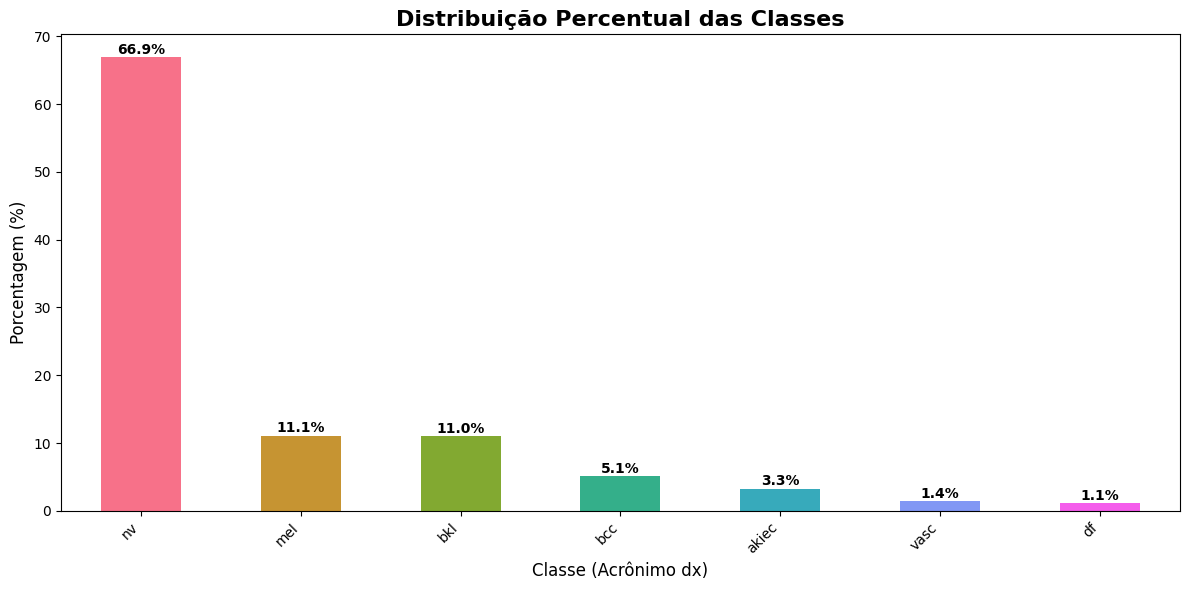

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Count by class using acronym (dx)
class_counts = metadata_df['dx'].value_counts()

# Convert to percentage
class_percent = (class_counts / class_counts.sum()) * 100

# Plot
class_percent.plot(kind='bar', ax=ax, color=sns.color_palette("husl", len(class_percent)))

ax.set_title('Distribuição Percentual das Classes', fontsize=16, fontweight='bold')
ax.set_xlabel('Classe (Acrônimo dx)', fontsize=12)
ax.set_ylabel('Porcentagem (%)', fontsize=12)
ax.set_xticklabels(class_percent.index, rotation=45, ha='right')

# Add percentage labels above bars
for i, v in enumerate(class_percent.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()   

Usando a coluna `dx`, foi calculada a contagem de imagens por classe e suas porcentagens.  
O gráfico de barras resultante mostra que o dataset é **fortemente desbalanceado**:

- a classe **`nv`** (nevos melanocíticos) concentra **mais da metade das imagens**;
- classes como **`df`** e **`vasc`** possuem pouco mais de uma centena de exemplos;
- as demais classes (**`akiec`**, **`bcc`**, **`bkl`**, **`mel`**) aparecem em quantidades intermediárias.

Esse desbalanceamento é problemático porque um modelo pode obter alta acurácia apenas “chutando” a classe majoritária.  

---

### 4. Distribuições globais dos metadados

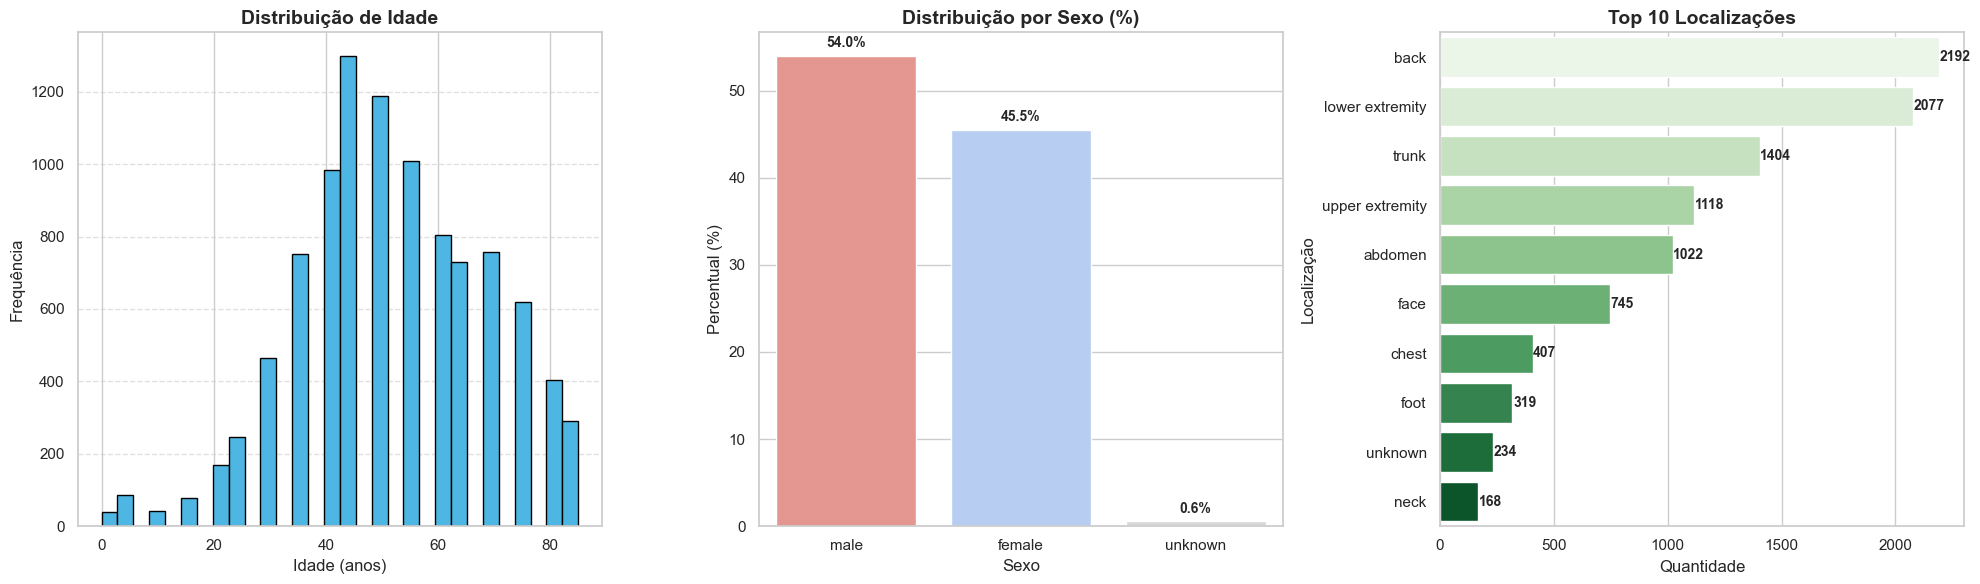

In [20]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# =========================================
# 1) Distribuição de Idade
# =========================================
axes[0].hist(metadata_df['age'].dropna(), bins=30, color='#4DB6E2', edgecolor='black')
axes[0].set_title('Distribuição de Idade', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Idade (anos)')
axes[0].set_ylabel('Frequência')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)



# =========================================
# 2) Distribuição por Sexo (em %)
# =========================================
sex_percent = metadata_df['sex'].value_counts(normalize=True) * 100
sex_df = sex_percent.reset_index()
sex_df.columns = ['sex', 'percent']

sns.barplot(
    data=sex_df,
    x='sex',
    y='percent',
    hue='sex',           
    palette=['#F28B82', '#AECBFA', '#D7D7D7'],
    legend=False,            
    ax=axes[1]
)

axes[1].set_title('Distribuição por Sexo (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Percentual (%)')
plt.setp(axes[1].get_xticklabels(), rotation=0)


# value labels
for i, v in enumerate(sex_percent.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=10, fontweight='bold')



# =========================================
# 3) Top 10 Localizações
# =========================================
top_loc = metadata_df['localization'].value_counts().head(10)
loc_df = top_loc.reset_index()
loc_df.columns = ['localization', 'count']

sns.barplot(
    data=loc_df,
    x='count',
    y='localization',
    hue='localization',   
    palette='Greens',
    legend=False,          
    ax=axes[2]
)

axes[2].set_title('Top 10 Localizações', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Quantidade')
axes[2].set_ylabel('Localização')

# labels
for i, v in enumerate(top_loc.values):
    axes[2].text(v + 3, i, str(v), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


Nesta etapa foi analisado a distribuição de **idade**, **sexo** e **localização anatômica** considerando todas as classes juntas.

- **Idade**  
  O histograma de `age` mostra idades aproximadamente entre 0 e 85 anos, com maior concentração em adultos de meia-idade e idosos.  
  Isso está de acordo com o comportamento esperado para doenças de pele, que tendem a ser mais frequentes em faixas etárias mais altas.

- **Sexo**  
  A variável `sex` é relativamente **balanceada** entre masculino e feminino, com leve predominância do sexo masculino e uma pequena fração de registros com sexo desconhecido.  
  Esse desbalanceamento leve não é crítico, mas vale ser monitorado caso os metadados sejam usados diretamente como entrada do modelo.

- **Localização anatômica**  
  A coluna `localization` é bastante **desigual**: regiões como *back*, *lower extremity* e *trunk* aparecem com muito mais frequência do que regiões raras como *ear*, *genital* ou *acral*.  
  Isso indica que o modelo pode ter mais dificuldade para generalizar bem em localizações pouco representadas.
---

### 5. Distribuições por classe (metadados condicionados ao diagnóstico)

In [21]:
def plot_demographics_for_class(df, class_code, class_label=None, n_top_loc=10):
    subset = df[df["dx"] == class_code]

    if subset.empty:
        print(f"⚠️ No samples for class '{class_code}'")
        return

    if class_label is None:
        class_label = class_code

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"Demographic distribution for class: {class_label} ({class_code})",
        fontsize=16, fontweight="bold", y=1.02
    )

    # 1) Age distribution
    axes[0].hist(subset["age"].dropna(), bins=20, color="#4DB6E2", edgecolor="black")
    axes[0].set_title("Age distribution", fontweight="bold")
    axes[0].set_xlabel("Age (years)")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(axis="y", linestyle="--", alpha=0.6)

    # 2) Sex distribution (in %)
    sex_percent = subset["sex"].value_counts(normalize=True) * 100
    sex_df = sex_percent.reset_index()
    sex_df.columns = ["sex", "percent"]
    base_colors = ["#F28B82", "#AECBFA", "#D7D7D7"]
    palette = base_colors[:len(sex_df)]

    sns.barplot(
        data=sex_df,
        x="sex",
        y="percent",
        hue="sex",         
        palette=palette,
        legend=False,
        ax=axes[1]
    )
    axes[1].set_title("Sex distribution (%)", fontweight="bold")
    axes[1].set_xlabel("Sex")
    axes[1].set_ylabel("Percentage (%)")
    plt.setp(axes[1].get_xticklabels(), rotation=0)

    for i, v in enumerate(sex_df["percent"]):
        axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

    # 3) Top locations (counts)
    top_loc = subset["localization"].value_counts().head(n_top_loc)
    loc_df = top_loc.reset_index()
    loc_df.columns = ["localization", "count"]

    sns.barplot(
        data=loc_df,
        x="count",
        y="localization",
        hue="localization",
        palette="Greens",
        legend=False,
        ax=axes[2]
    )
    axes[2].set_title("Top locations", fontweight="bold")
    axes[2].set_xlabel("Count")
    axes[2].set_ylabel("Location")

    for i, v in enumerate(loc_df["count"]):
        axes[2].text(v + 0.5, i, str(v), va="center", fontsize=9, fontweight="bold")

    plt.tight_layout()
    plt.show()

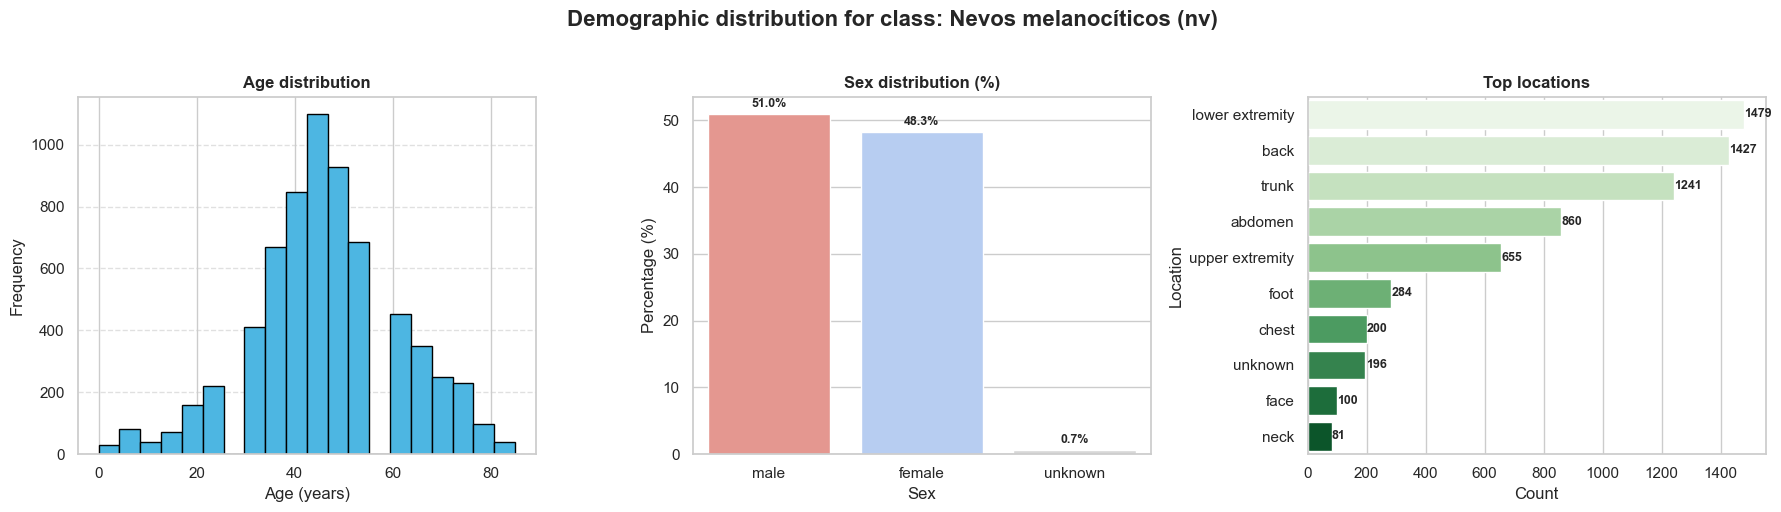

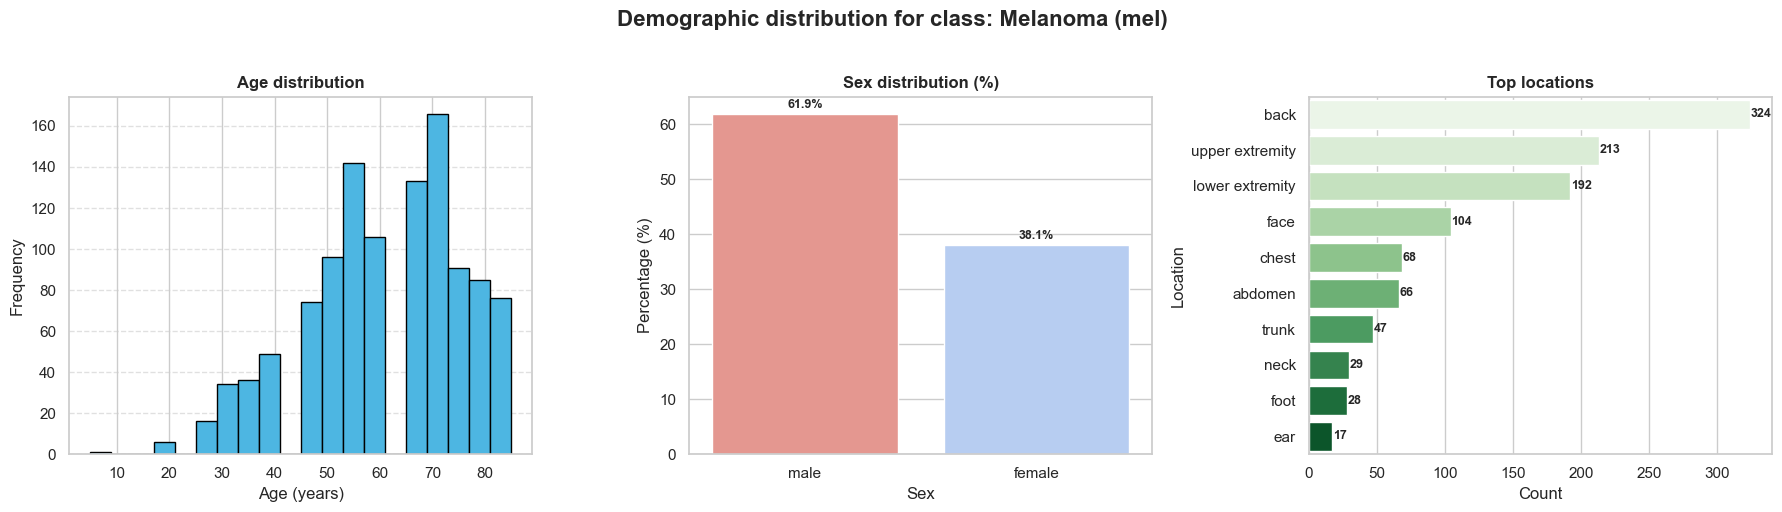

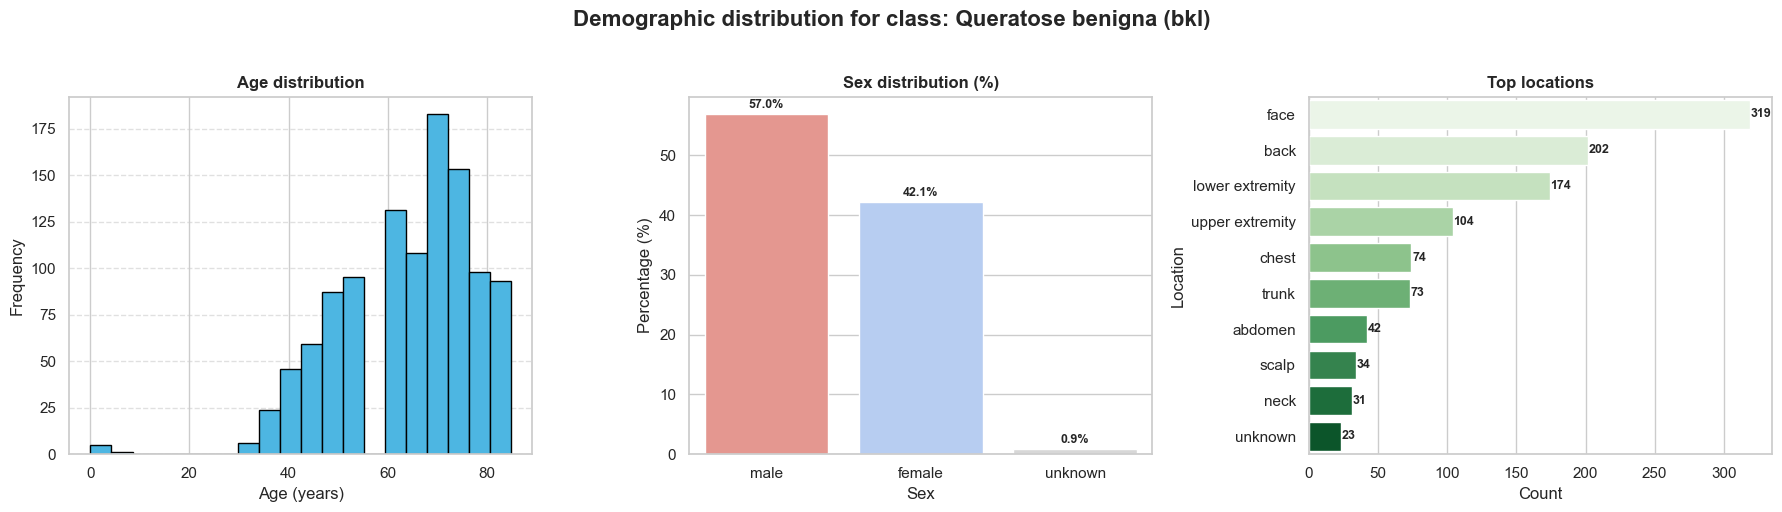

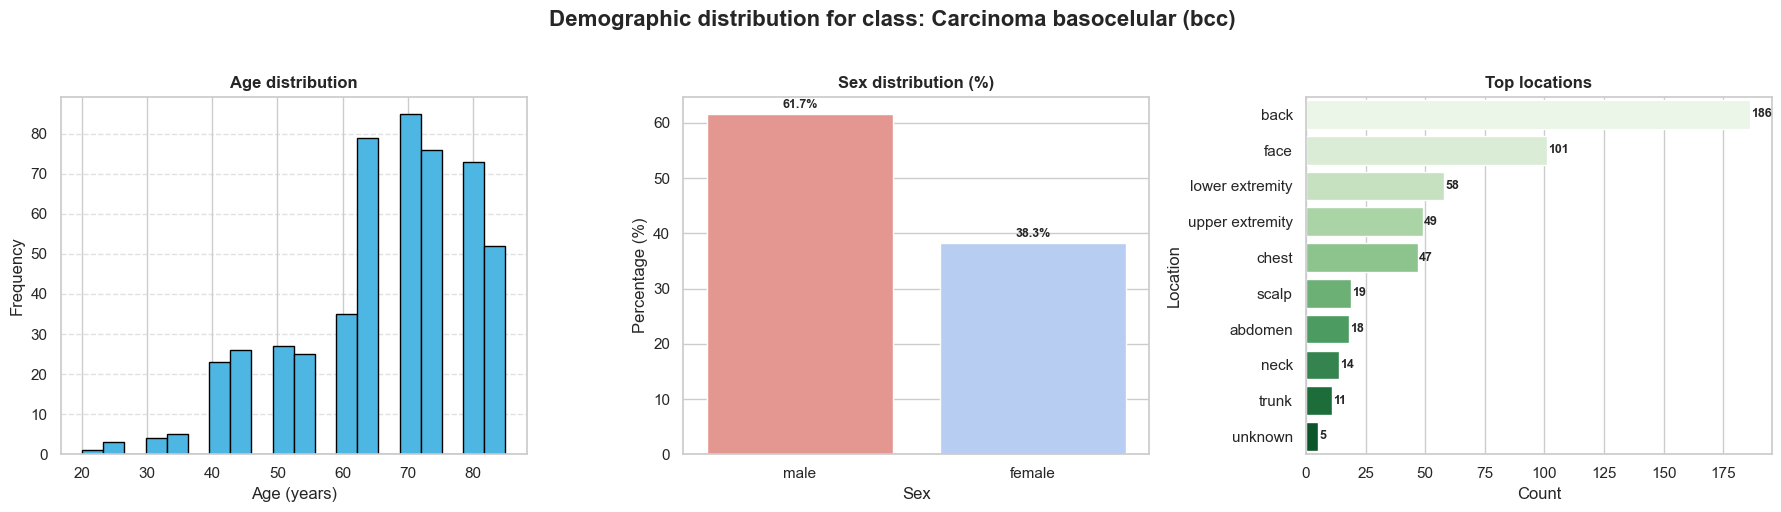

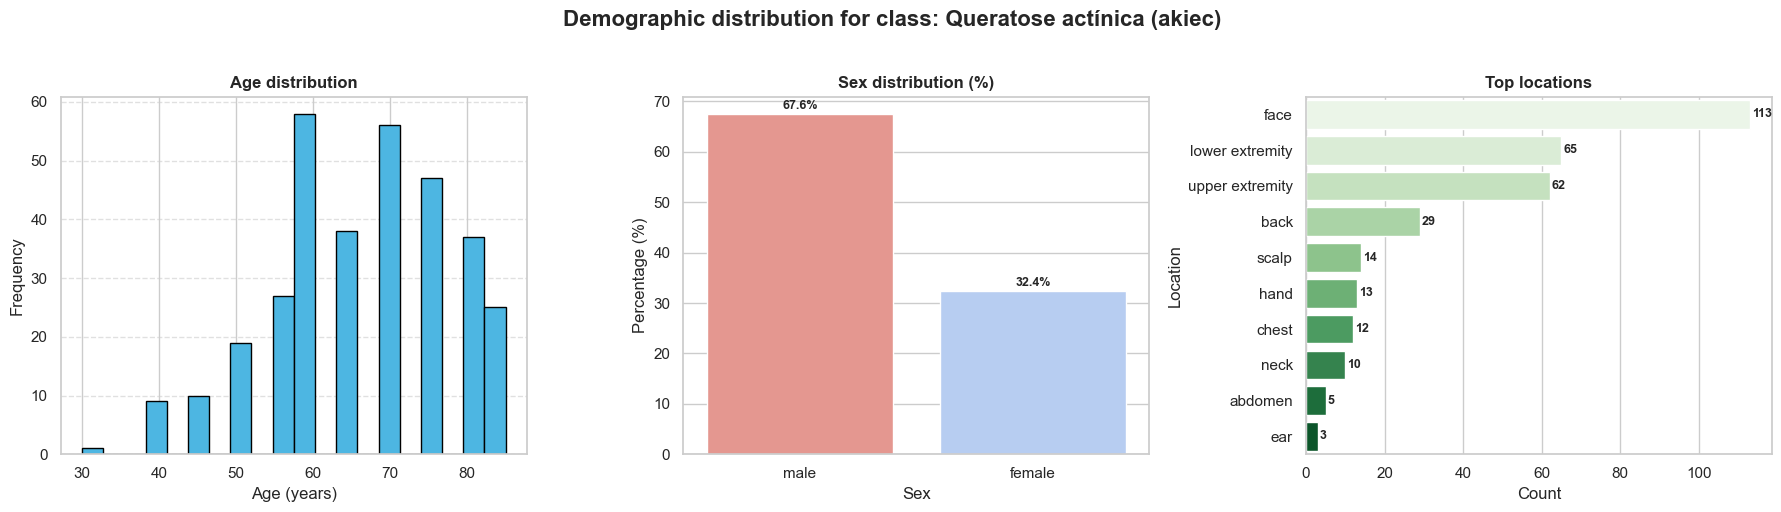

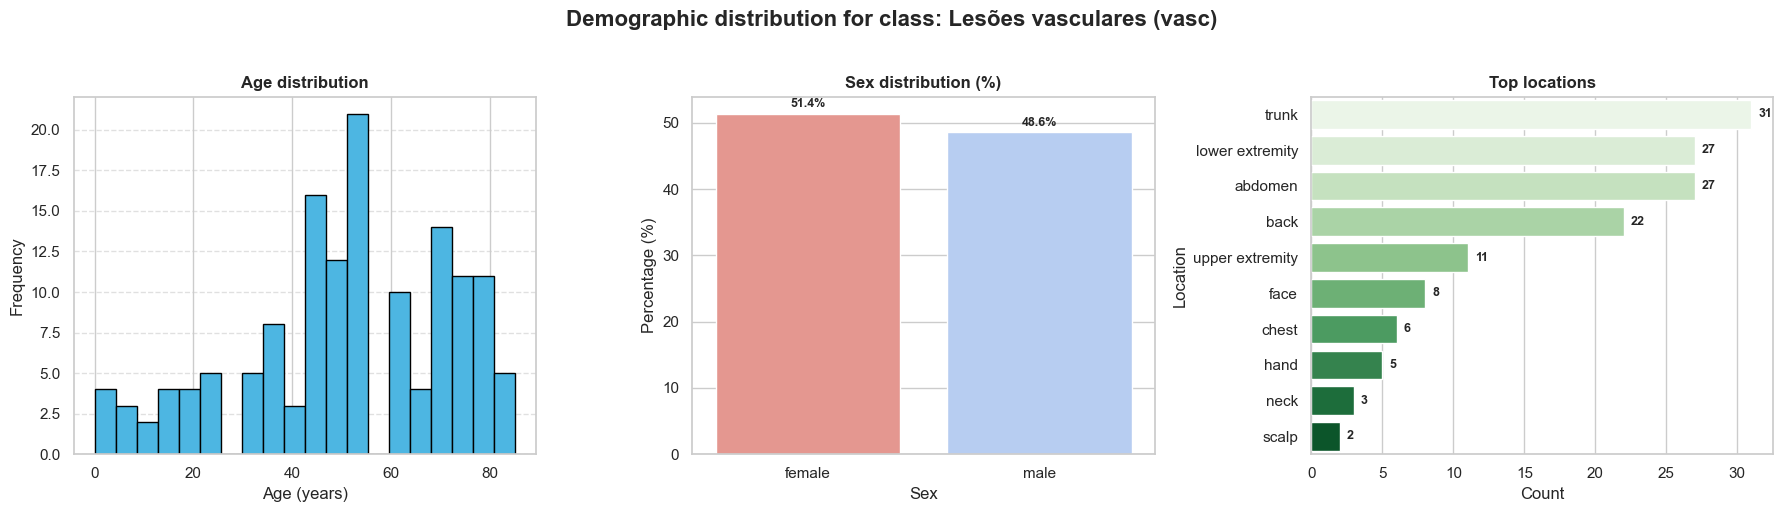

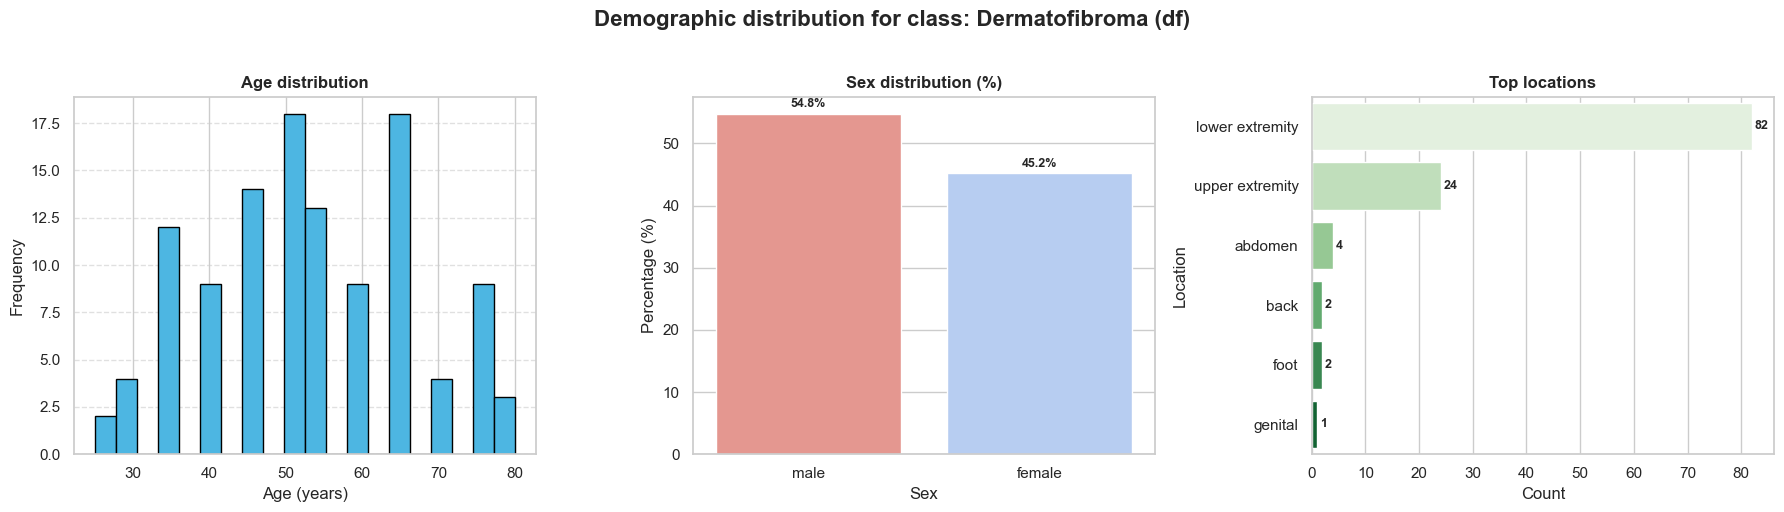

In [22]:
for cls in class_names: 
    plot_demographics_for_class(metadata_df, cls, class_names.get(cls, cls))

A função `plot_demographics_for_class` gera, para cada classe, gráficos com:

- histograma de idades;
- distribuição de sexo;
- distribuição das localizações anatômicas.

Essa análise **condicionada ao diagnóstico** ajuda a entender melhor o contexto clínico de cada classe:

- algumas lesões aparecem mais em determinadas faixas etárias;
- a proporção entre homens e mulheres pode variar entre diagnósticos;
- certas classes são mais comuns em regiões específicas do corpo (por exemplo, tronco/costas vs. extremidades).

Esses padrões mostram que os metadados trazem informação relevante e podem ser úteis em **modelos multimodais** (imagem + metadados).  
Ao mesmo tempo, evidenciam possíveis **vieses de amostragem**: se uma classe aparece quase sempre em uma região do corpo, o modelo pode aprender atalhos que não generalizam bem para outros cenários.

---

### 6. Análise das imagens

#### 6.1 Propriedades gerais das imagens

In [23]:
widths = []
heights = []
modes = []
formats = []
corrupted = []

for path in metadata_df["image_path"]:
    try:
        with Image.open(path) as img:
            widths.append(img.width)
            heights.append(img.height)
            modes.append(img.mode)
            formats.append(img.format)
    except:
        corrupted.append(path)

# Cria df com informações das imagens
img_info = pd.DataFrame({
    "width": widths,
    "height": heights,
    "mode": modes,
    "format": formats
})

print("Dimensões:")
print(img_info[["width", "height"]].describe(), "\n")

print("Modos de Cor:")
print(img_info["mode"].value_counts(), "\n")

print("Formatos das Imagens:")
print(img_info["format"].value_counts(), "\n")

if len(corrupted) > 0:
    print("⚠️ Imagens corrompidas encontradas:")
    for path in corrupted:
        print(" -", path)
else:
    print("Nenhuma imagem corrompida encontrada.")

Dimensões:
         width   height
count  10015.0  10015.0
mean     600.0    450.0
std        0.0      0.0
min      600.0    450.0
25%      600.0    450.0
50%      600.0    450.0
75%      600.0    450.0
max      600.0    450.0 

Modos de Cor:
mode
RGB    10015
Name: count, dtype: int64 

Formatos das Imagens:
format
JPEG    10015
Name: count, dtype: int64 

Nenhuma imagem corrompida encontrada.


A partir da coluna `image_path`, foram obtidos os dados:

- largura (`width`);
- altura (`height`);
- modo de cor (`mode`);
- formato (`format`).

No HAM10000, observa-se que:

- todas as imagens são **coloridas (RGB)**;
- possuem resolução aproximada de **600 × 450 pixels**;
- estão salvas, em geral, no formato **JPEG**.

Essa homogeneidade de tamanho e formato reduz o esforço de pré-processamento, pois permite definir uma etapa única de resize e normalização antes de alimentar a rede neural.

#### 6.2 Exemplos visuais por classe

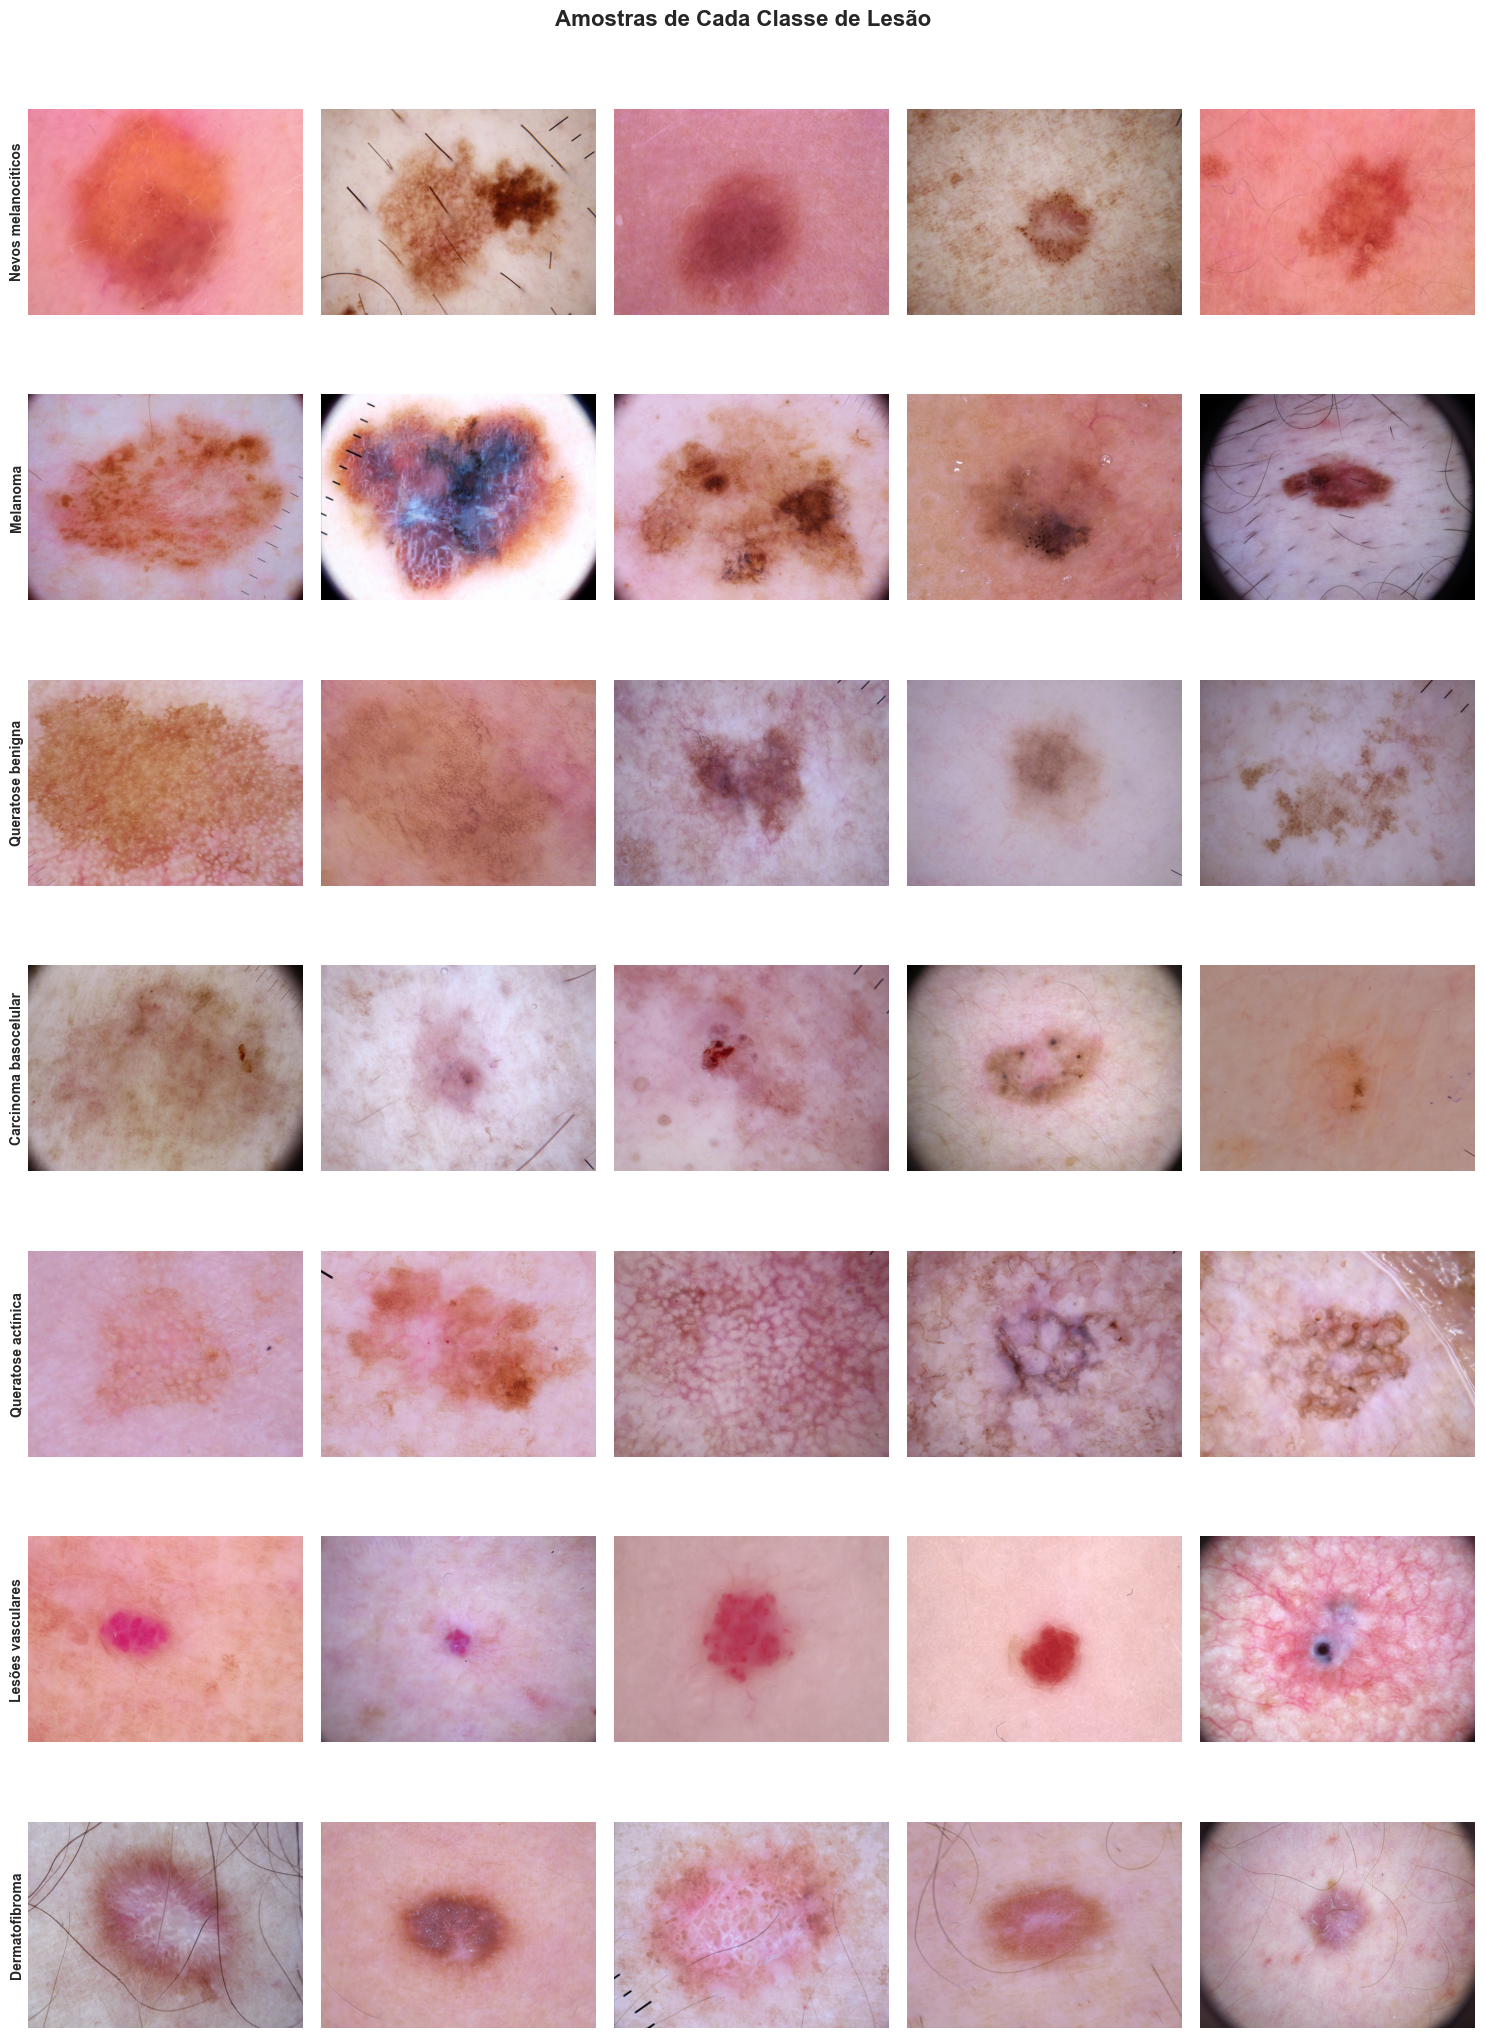

In [24]:
# Plotar 5 exemplos de cada classe
n_samples = 5
fig, axes = plt.subplots(num_classes, n_samples, figsize=(n_samples * 3, num_classes * 3))

for idx, (class_code, class_label) in enumerate(class_names.items()):
    # Pegar amostras aleatórias da classe
    class_df = metadata_df[metadata_df['dx'] == class_code]
    n_available = min(n_samples, len(class_df))
    class_samples = class_df.sample(n_available, random_state=SEED)
    
    for col, (_, row) in enumerate(class_samples.iterrows()):
        img = Image.open(row['image_path'])
        axes[idx, col].imshow(img)
        axes[idx, col].axis('off')
        
        # Adicionar título apenas na primeira coluna
        if col == 0:
            axes[idx, col].text(-10, img.size[1]//2, class_label, 
                              fontsize=10, fontweight='bold', 
                              rotation=90, va='center', ha='right')

plt.suptitle('Amostras de Cada Classe de Lesão', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

A partir das imagens é possível notar alguns padrões, dentre eles os três mais nítidos são:

- **Lesões vasculares (`vasc`)** tendem a apresentar coloração mais avermelhada e áreas bem delimitadas;
- **Melanomas (`mel`)** costumam ser mais escuros, com bordas irregulares e variação de tonalidade dentro da mesma lesão;
- **Dermatofibromas (`df`)** frequentemente exibem uma região central mais clara ou esbranquiçada;

---

## Preprocessamento

O objetivo desta etapa é transformar as imagens brutas do dataset em tensores normalizados e prontos para treinar a rede neural.

---

### Carregamento e Processamento de Imagem

In [25]:
print(f"Carregando e redimensionando {len(metadata_df)} imagens para {IMG_WIDTH}x{IMG_HEIGHT}...")
print("Isso pode levar alguns minutos...")

# Função para carregar e redimensionar imagem
def load_and_resize_image(path):
    try:
        img = Image.open(path)
        img = img.resize((IMG_WIDTH, IMG_HEIGHT))
        return np.array(img)
    except Exception as e:
        print(f"Erro ao carregar {path}: {e}")
        return None

# Carregar imagens
metadata_df['image_array'] = metadata_df['image_path'].apply(load_and_resize_image)

# Remover imagens que falharam
metadata_df = metadata_df.dropna(subset=['image_array'])

print(f"{len(metadata_df)} imagens carregadas com sucesso!")


Carregando e redimensionando 10015 imagens para 128x128...
Isso pode levar alguns minutos...
10015 imagens carregadas com sucesso!


In [26]:
# Verificar distribuição de tamanhos
shapes = metadata_df['image_array'].apply(lambda x: x.shape).value_counts()
print("Distribuição de shapes:")
print(shapes)



Distribuição de shapes:
image_array
(128, 128, 3)    10015
Name: count, dtype: int64


As imagens são carregadas a partir dos caminhos presentes no `metadata_df['image_path']`. Cada imagem é:

- Aberta e convertida para RGB;

- Redimensionada para IMG_WIDTH x IMG_HEIGHT pixels;

- Convertida para um numpy.array do tipo float32.

---

### Train-Test Split

In [27]:
# Preparar features (X) e labels (y)
X = np.array(metadata_df['image_array'].tolist())
y = metadata_df['class_idx'].values

print("Shape dos dados:")
print(f"X: {X.shape}")
print(f"y: {y.shape}")


Shape dos dados:
X: (10015, 128, 128, 3)
y: (10015,)


A partir da coluna image_array, é construído o tensor de features:

- `X`: tensor de formato (N, 128, 128, 3), onde N é o número de imagens.

Os rótulos numéricos das classes são obtidos de `metadata_df['class_idx']`:

- `y`: vetor de tamanho N contendo o índice da classe de cada imagem.

Essa é a base para a divisão em treino, validação e teste.

In [28]:
# Primeira divisão: Train e Test 
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=SEED,
    stratify=y
)

val_relative_size = VAL_SIZE / (1.0 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=val_relative_size,
    random_state=SEED,
    stratify=y_train_full
)
print("Divisão dos dados:")
print(f"    Treino:     {X_train.shape[0]:5d} imagens ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"    Validação:  {X_val.shape[0]:5d} imagens ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"    Teste:      {X_test.shape[0]:5d} imagens ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"    TOTAL:      {len(X):5d} imagens")


Divisão dos dados:
    Treino:      7009 imagens (70.0%)
    Validação:   1503 imagens (15.0%)
    Teste:       1503 imagens (15.0%)
    TOTAL:      10015 imagens


Os dados são divididos em três subconjuntos, mantendo a proporção original das classes (estratificação):

- Treino: 70% das imagens

- Validação: 15% das imagens

- Teste: 15% das imagens

A divisão é feita em duas etapas:

- Separação inicial de teste a partir do conjunto completo;

- Divisão do restante entre treino e validação, usando uma fração relativa (para manter as porcentagens desejadas).

---

### Padronização

In [29]:
# Calcular média e desvio padrão do conjunto de treino
X_train_mean = np.mean(X_train)
X_train_std = np.std(X_train)

print("Conjunto de treino (antes da normalização):")
print(f"Média: {X_train_mean:.2f}")
print(f"Desvio padrão: {X_train_std:.2f}")
print(f"Min: {X_train.min()}")
print(f"Max: {X_train.max()}")

# Padronização (z-score)
X_train = (X_train - X_train_mean) / X_train_std
X_val   = (X_val   - X_train_mean) / X_train_std
X_test  = (X_test  - X_train_mean) / X_train_std

print("Após normalização (padronização):")
print(f"Média: {X_train.mean():.6f}")
print(f"Desvio padrão: {X_train.std():.6f}")

Conjunto de treino (antes da normalização):
Média: 159.90
Desvio padrão: 46.65
Min: 0
Max: 255
Após normalização (padronização):
Média: -0.000000
Desvio padrão: 1.000000


A normalização é feita **apenas com base no conjunto de treino**, evitando vazamento de informação entre os conjuntos.

1. Calcula-se a **média** e o **desvio padrão** de todos os pixels de `X_train`.
2. Cada conjunto (`X_train`, `X_val`, `X_test`) é padronizado usando: $X' = \frac{X - \mu_{\text{train}}}{\sigma_{\text{train}}}$

Após a padronização:

* O conjunto de **treino** passa a ter média ≈ 0 e desvio padrão ≈ 1;
* Os conjuntos de **validação** e **teste** são transformados usando os mesmos parâmetros do treino.


---

### One-Hot Encoding Labels Numéricos

In [30]:
# One-hot encoding
y_train_encoded = to_categorical(y_train, num_classes=num_classes)
y_val_encoded = to_categorical(y_val, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

print("Exemplo de encoding:")
print(f"   Label original: {y_train[0]}")
print(f"   One-hot encoded: {y_train_encoded[0]}")

Exemplo de encoding:
   Label original: 5
   One-hot encoded: [0. 0. 0. 0. 0. 1. 0.]


Os rótulos numéricos (`y_train`, `y_val`, `y_test`) são convertidos para vetores *one-hot* utilizando `num_classes` como dimensão:

* `y_train_encoded`
* `y_val_encoded`
* `y_test_encoded`


---

## Módulos

Os módulos são trechos de códigos utilizados para o proccessamento, treinamento e demonstração dos dados.

---

### Modelos

In [54]:
def build_simple_cnn(input_shape, num_classes):
    """
    Cria uma CNN simples usada como primeiro modelo convolucional.

    Arquitetura:
    - Bloco 1: 2 convoluções (32 filtros) + MaxPooling + Dropout(0.25)
    - Bloco 2: 2 convoluções (64 filtros) + MaxPooling + Dropout(0.40)
    - Cabeça densa: Flatten + Dense(128) + Dropout(0.5) + Dense(num_classes, softmax)
    """
    model = Sequential()

    # --- Input layer ---
    model.add(Input(shape=input_shape))

    # Bloco 1
    model.add(Conv2D(32, kernel_size=(3, 3),
                     activation='relu', padding='same'))
    model.add(Conv2D(32, kernel_size=(3, 3),
                     activation='relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Bloco 2
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.40))

    # Cabeça densa
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

---

### Gráficos

In [36]:
def plot_history(history, model_name="Modelo"):
    """
    Plota as curvas de treino/validação de accuracy e loss.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Treino')
    axes[0].plot(history.history['val_accuracy'], label='Validação')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(loc='best')
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Treino')
    axes[1].plot(history.history['val_loss'], label='Validação')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(loc='best')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [50]:
def print_accuracy_summary(model_name, y_val_true, y_val_pred,
                           y_test_true, y_test_pred):
    """
    Imprime acurácia em validação e teste no mesmo formato
    usado para o modelo Dummy e para as CNNs.
    """
    acc_val = accuracy_score(y_val_true, y_val_pred)
    acc_test = accuracy_score(y_test_true, y_test_pred)
    print("=" * 70)
    print(f"{model_name}:")
    print("=" * 70)
    print(f"Acurácia Validação: {acc_val * 100:.2f}%")
    print(f"Acurácia Teste:     {acc_test * 100:.2f}%")


def plot_confusion_and_report(y_true, y_pred, class_names, model_name):
    """
    Plota a matriz de confusão e imprime o classification_report
    com o mesmo estilo das seções do notebook.
    """
    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=list(class_names.keys()),
        yticklabels=list(class_names.keys()),
    )
    plt.title(f'Matriz de Confusão - {model_name}', fontsize=14, fontweight='bold')
    plt.ylabel('Classe Verdadeira')
    plt.xlabel('Classe Predita')
    plt.tight_layout()
    plt.show()

    # Relatório de classificação
    print(f"RELATÓRIO DE CLASSIFICAÇÃO - {model_name.upper()}:")
    print("=" * 80)
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=list(class_names.values()),
            digits=4,
            zero_division=0
        )
    )
    print("=" * 80)

---

## Modelo Dummy

Antes de treinar modelos mais complexos, é importante definir um **baseline**. Como baseline foi utilizado o **modelo dummy**, que ignora completamente as imagens e sempre prediz a **classe mais frequente** do conjunto de treino. Esse modelo serve como referência mínima: outroso modelos precisam performar melhor do que ele, especialmente nas classes minoritárias.

---

### Como o modelo Dummy funciona?

Utilizamos o `DummyClassifier` do `sklearn` com a estratégia:

- `strategy='most_frequent'`: o classificador aprende apenas qual é a classe que mais aparece em `y_train` e passa a sempre retornar essa classe,
independentemente da entrada

Esse comportamento é adequado para evidenciar o **desbalanceamento do dataset**: se uma única classe é muito comum, o modelo pode ter uma acurácia razoável,
mas será péssimo nas demais classes.

---


### Treinamento e Avaliação do Dummy

In [47]:
# Modelo dummy que sempre prediz a classe majoritária
dummy_model = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy_model.fit(X_train, y_train)

print("Modelo dummy treinado!")

Modelo dummy treinado!


In [ ]:
# Predições
y_pred_val = dummy_model.predict(X_val)
y_pred_test = dummy_model.predict(X_test)

# Acurácias
print_accuracy_summary("Dummy Classifier", y_val, y_pred_val, y_test, y_pred_test)

Dummy Classifier:
Acurácia Validação: 66.93%
Acurácia Teste:     66.93%


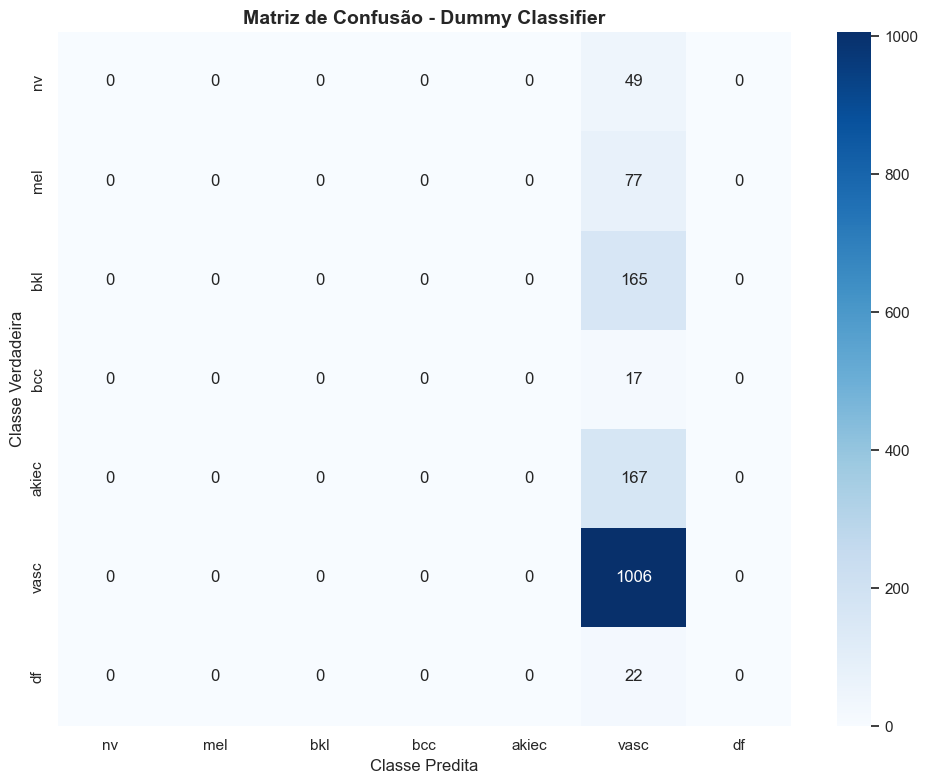

RELATÓRIO DE CLASSIFICAÇÃO - DUMMY CLASSIFIER:
                       precision    recall  f1-score   support

  Nevos melanocíticos     0.0000    0.0000    0.0000        49
             Melanoma     0.0000    0.0000    0.0000        77
    Queratose benigna     0.0000    0.0000    0.0000       165
Carcinoma basocelular     0.0000    0.0000    0.0000        17
   Queratose actínica     0.0000    0.0000    0.0000       167
    Lesões vasculares     0.6693    1.0000    0.8019      1006
       Dermatofibroma     0.0000    0.0000    0.0000        22

             accuracy                         0.6693      1503
            macro avg     0.0956    0.1429    0.1146      1503
         weighted avg     0.4480    0.6693    0.5367      1503



In [51]:
plot_confusion_and_report(y_test, y_pred_test, class_names, "Dummy Classifier")

O modelo dummy alcançou cerca de **66–67%** de acurácia simplesmente por sempre predizer a classe mais frequente.

**Pontos importantes:**

- A matriz de confusão mostra que a maior parte dos acertos está concentrada na classe majoritária
- Apesar da acurácia as classes raras **não são reconhecidas**

A partir deste baseline, todos os modelos subsequentes devem superar claramente esse desempenho, principalmente em termos de equilíbrio entre as classes.


---

## Redes Neurais Convolucionais (CNNs)

Nesta seção foram treinados modelos de **Redes Neurais Convolucionais (CNNs)** para classificar as imagens de lesões de pele.

São testadas as seguintes variações principais:

1. **CNN simples** — arquitetura base, sem técnicas de balanceamento;
2. **CNN com pesos de classe** — ajusta a função de loss para penalizar mais erros em classes raras;
3. **CNN com oversampling** — equilibra o número das classes de treino para reforçar as classes minoritárias.

Antes de mostrar os modelos, será explicado rapidamente o que é uma CNN e como ela foi declarada neste projeto.

---

### 1. CNNs Conceito

Uma **CNN (Convolutional Neural Network)** é um tipo de rede neural projetada para trabalhar com **dados em grade**, como imagens. No nosso problema, cada imagem de pele é representada como um tensor `(altura, largura, canais)`, por exemplo `(IMG_HEIGHT, IMG_WIDTH, CHANNELS)`.

Os principais blocos de uma CNN são:

1. **Camadas convolucionais (`Conv2D`)**  
   - Aplicam filtros (kernels) que “varrem” a imagem
   - Cada filtro aprende a detectar padrões locais
   - A saída são **mapas de ativação** que destacam regiões onde esses padrões foram encontrados

2. **Função de ativação (`ReLU`)**  
   - Introduz não-linearidade, permitindo que a rede aprenda relações mais complexas
   - Mantém apenas valores positivos, o que ajuda na estabilidade do treino
   - Evita "vanishing gradient"

    $\text{ReLU}(z) =
    \begin{cases}
    0, & \text{if } z < 0 \\
    z, & \text{if } z \ge 0 \\
    \end{cases}$

3. **Camadas de pooling (`MaxPooling2D`)**  
   - Reduzem a resolução espacial dos mapas de ativação
   - Mantêm apenas a informação mais “forte” (por exemplo, o valor máximo em um bloco 2×2), tornando o modelo mais robusto a pequenas variações e
deslocamentos na imagem

4. **Dropout**  
   - Zera aleatoriamente uma fração das ativações durante o treino;
   - Ajuda a evitar **overfitting**, fazendo a rede depender menos de neurônios específicos.

5. **Flatten + camadas densas (`Dense`)**  
   - Depois de várias convoluções/pooling, os mapas de ativação são “achatados” em um vetor 1D (`Flatten`)
   - Esse vetor é passado por camadas densas que funcionam como um classificador tradicional
   - A última camada usa `softmax` para produzir uma **distribuição de probabilidades** sobre as `num_classes` de lesões

    $\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$

---

### 2. Declaração CNN

Foi utilizada a API `Sequential` do Keras:

- `input_shape = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)` define o formato das imagens;
- Dois blocos convolucionais:
  - Bloco 1: duas `Conv2D(32, 3×3)` + `MaxPooling2D` + `Dropout(0.25)`
  - Bloco 2: duas `Conv2D(64, 3×3)` + `MaxPooling2D` + `Dropout(0.40)`
- Cabeça densa:
  - `Flatten()` → `Dense(128, activation='relu')` → `Dropout(0.5)` → `Dense(num_classes, activation='softmax')`

---

### 3. CNN Simples

Nesta primeira arquitetura convolucional usamos uma CNN “padrão”, sem técnicas explícitas de balanceamento. O objetivo é verificar quanto já ganhamos em relação ao modelo dummy apenas explorando a estrutura espacial das imagens.

- Entrada do Modelo: imagens redimensionadas e padronizadas

---

#### Implementação

In [106]:
# 1. Construção do modelo
input_shape = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)
model_cnn_simple = build_simple_cnn(input_shape, num_classes)
model_cnn_simple.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,455,207 (32.25 MB)

 Trainable params: 8,455,207 (32.25 MB)

 Non-trainable params: 0 (0.00 B)

In [107]:
# 2. Compilação
optimizer = Adam(learning_rate=0.0005)

model_cnn_simple.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

# Callback para reduzir LR quando a validação "satura"
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    verbose=1,
    factor=0.5,
    min_lr=1e-5,
)

print("CNN Simples compilada!")

CNN Simples compilada!


In [108]:
# 3. Treinamento
history_cnn_simple = model_cnn_simple.fit(
    X_train, y_train_encoded,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val_encoded),
    callbacks=[learning_rate_reduction],
    verbose=1,
)
print("CNN Simples treinada!")

Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 49s 212ms/step - accuracy: 0.6643 - loss: 1.0380 - val_accuracy: 0.6753 - val_loss: 0.9136 - learning_rate: 5.0000e-04
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 43s 196ms/step - accuracy: 0.6798 - loss: 0.8950 - val_accuracy: 0.6820 - val_loss: 0.8532 - learning_rate: 5.0000e-04
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 43s 193ms/step - accuracy: 0.6891 - loss: 0.8423 - val_accuracy: 0.6973 - val_loss: 0.8182 - learning_rate: 5.0000e-04
Epoch 4/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 43s 194ms/step - accuracy: 0.7095 - loss: 0.7966 - val_accuracy: 0.7112 - val_loss: 0.7731 - learning_rate: 5.0000e-04
Epoch 5/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 47s 212ms/step - accuracy: 0.7168 - loss: 0.7577 - val_accuracy: 0.7219 - val_loss: 0.7694 - learning_rate: 5.0000e-04
Epoch 6/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 55s 249ms/step - accuracy: 0.7339 - loss: 0.7160 - val_accuracy: 0.7272 - val_loss: 0.7602 - learning_rate: 5.0000e-04
Epoch 7/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 52s 23

In [109]:
model_cnn_simple.save("models/cnn/simple.keras")
print("CNN Simples salva!")

CNN Simples salva!


---

#### Resultados

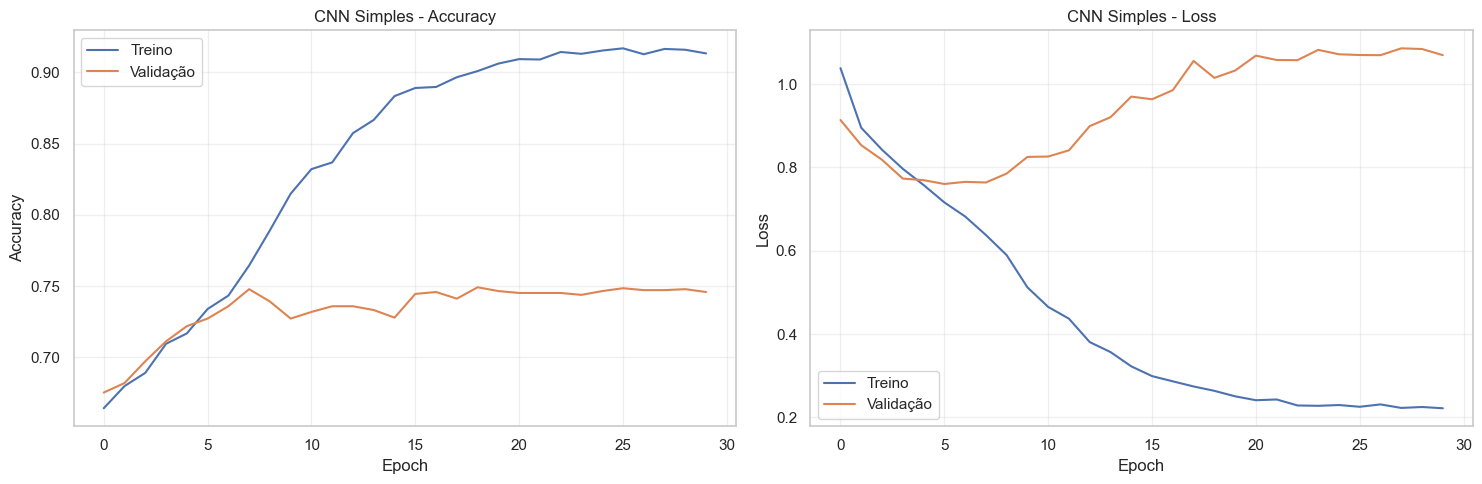

In [113]:
# 4. Curvas de treino/validação
plot_history(history_cnn_simple, model_name="CNN Simples")

A rede está **aprendendo bem no conjunto de treino**, mas depois de algumas épocas ela estagna para o conjunto de validação. Além do mais, é possível observar:

- Gap grande entre accuracy de treino (~94%) e validação (~74%);
- Loss de validação subindo enquanto o de treino continua caindo o que indica **overfitting**.

In [111]:
simple_model = load_model("models/cnn/simple.keras")
print("CNN Simples carregada!")

CNN Simples carregada!


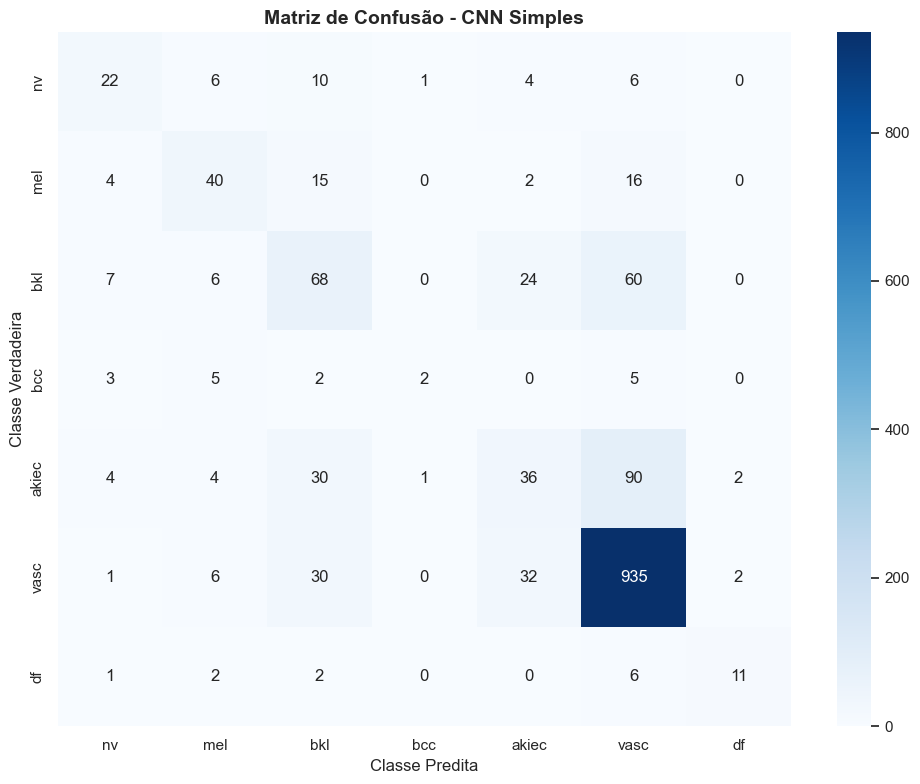

RELATÓRIO DE CLASSIFICAÇÃO - CNN SIMPLES:
                       precision    recall  f1-score   support

  Nevos melanocíticos     0.5238    0.4490    0.4835        49
             Melanoma     0.5797    0.5195    0.5479        77
    Queratose benigna     0.4331    0.4121    0.4224       165
Carcinoma basocelular     0.5000    0.1176    0.1905        17
   Queratose actínica     0.3673    0.2156    0.2717       167
    Lesões vasculares     0.8363    0.9294    0.8804      1006
       Dermatofibroma     0.7333    0.5000    0.5946        22

             accuracy                         0.7412      1503
            macro avg     0.5677    0.4490    0.4844      1503
         weighted avg     0.7113    0.7412    0.7205      1503



In [116]:
# 5. Avaliação em teste: matriz de confusão + relatório
y_pred_cnn_simple = simple_model.predict(X_test, verbose=0)
y_pred_classes_cnn_simple = np.argmax(y_pred_cnn_simple, axis=1)

plot_confusion_and_report(
    y_true=y_test,
    y_pred=y_pred_classes_cnn_simple,
    class_names=class_names,
    model_name="CNN Simples",
)

1. Métricas globais
  - **Acurácia 74,1%**: melhor que o `dummy`, o que indica que a CNN de fato está aprendendo padrões visuais úteis.
  - **Macro avg (média simples entre classes)**:
    - recall médio ≈ 0,45 e F1 ≈ 0,48 → desempenho **médio** quando olhamos todas as classes de forma igual.
  - **Weighted avg (ponderado pelo número de exemplos)**:
    - recall ≈ 0,74, F1 ≈ 0,72 → como a base é altamente desbalanceada, o modelo parece “bom” porque acerta muito a classe majoritária.

Desse modo: **para o dataset como um todo** o modelo parece razoável, mas quando damos o mesmo peso para todas as classes, o desempenho cai bastante. 


2. Métricas por classe

Focando em recall (sensibilidade) e F1:

| Classe                | support | precision | recall | f1-score | Comentário                                                                                                     |
| --------------------- | ------- | --------- | ------ | -------- | -------------------------------------------------------------------------------------------------------------- |
| Nevos melanocíticos   | 49      | 0.52      | 0.45   | 0.48     | Acerta **quase metade** dos nevos; ainda confunde uma parte relevante com outras lesões.                      |
| Melanoma              | 77      | 0.58      | 0.52   | 0.55     | **Pouco mais da metade dos melanomas são detectados**; cerca de metade das predições de melanoma estão corretas. |
| Queratose benigna     | 165     | 0.43      | 0.41   | 0.42     | Desempenho pior que melanoma                                                 |
| Carcinoma basocelular | 17      | 0.50      | 0.12   | 0.19     | Recall bem baixo (~12%): o modelo **quase nunca reconhece** essa classe.                                |
| Queratose actínica    | 167     | 0.37      | 0.22   | 0.27     | Muitas queratoses actínicas sendo rotuladas como outras classes. Cerca de 1/4 encontrado.                                    |
| Lesões vasculares     | 1006    | 0.84      | 0.93   | 0.88     | **Classe majoritária**. Aqui o modelo é excelente: acerta a grande maioria dos casos vasculares.              |
| Dermatofibroma        | 22      | 0.73      | 0.50   | 0.59     | Quando indica dermatofibroma, geralmente está certo, mas encontra somente **metade** dos casos.          |

- A rede ficou **muito boa em “Lesões vasculares”** (que dominam o conjunto de dados).
- Nas classes com **poucos exemplos** (carcinoma basocelular, dermatofibroma, nevos etc.), o recall encontrado é baixo, embora algumas tenham melhorado em relação ao baseline.

3. Conclusão

A CNN simples **supera o baseline dummy** e aprende padrões visuais relevantes. Porém, é **fortemente enviesada** para a classe majoritária (“Lesões vasculares”), apresentando desempenho mediano/baixo nas classes menos frequentes. Esse comportamento é indesejado, uma vez que em cenários clínicos falsos negativos são críticos.

---

### 4. CNN com Pesos de Classes

Com o intuito de mitigar o problema do desbalanceamento do dataset observado no modelo anterior, a arquitetura atual implementou **pesos de classe** (*class weights*).

> “Erros em classes raras são mais graves do que erros em classes comuns.”

Assim, a loss passa a penalizar mais os erros nas classes com poucos exemplos, incentivando o modelo a prestar mais atenção nelas.

---

#### Como os pesos de classe são calculados?

Foi utilizada a função `compute_class_weight` do `sklearn`, com a estratégia `balanced`. A fórmula básica é:

$w_c = \frac{N}{n_c \cdot K}$

onde:

- $( N )$ é o número total de amostras,
- $( K )$ é o número de classes,
- $( n_c )$ é o número de amostras da classe $( c )$,
- $( w_c )$ é o peso atribuído à classe $( c )$.

Intuição:

- quanto **menor** $( n_c )$, **maior** será $( w_c )$;
- classes raras recebem pesos grandes, classes comuns recebem pesos menores.

Esses pesos são passados ao `model.fit` no argumento `class_weight`, que faz com que a função de loss “cobre mais caro” os erros nas classes minoritárias.


In [72]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train,
)

# Converte para dicionário {classe: peso} no formato que o Keras espera
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print("Pesos das classes:")

for idx, (code, name) in enumerate(class_names.items()):
    count = (y_train == idx).sum()
    weight = class_weight_dict[idx]
    print(f"  Classe {idx} ({code:6s}): peso = {weight:.2f} ({count:4d} imagens)")

Pesos das classes:
  Classe 0 (nv    ): peso = 4.37 ( 229 imagens)
  Classe 1 (mel   ): peso = 2.78 ( 360 imagens)
  Classe 2 (bkl   ): peso = 1.30 ( 769 imagens)
  Classe 3 (bcc   ): peso = 12.52 (  80 imagens)
  Classe 4 (akiec ): peso = 1.29 ( 779 imagens)
  Classe 5 (vasc  ): peso = 0.21 (4693 imagens)
  Classe 6 (df    ): peso = 10.11 (  99 imagens)


---

#### Implementação

A única diferença em relação à CNN simples está na maneira como a loss é calculada durante o treino: agora ela leva em conta os **pesos de classe** definidos acima.

In [101]:
# 1. Construção do modelo
input_shape = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)
model_cnn_weights = build_simple_cnn(input_shape, num_classes)

model_cnn_weights.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,455,207 (32.25 MB)

 Trainable params: 8,455,207 (32.25 MB)

 Non-trainable params: 0 (0.00 B)

In [102]:
# 1. Compilação com LR ajustado
optimizer = Adam(learning_rate=0.0005)

model_cnn_weights.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

learning_rate_reduction_weights = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    verbose=1,
    factor=0.5,
    min_lr=1e-6
)

print("CNN com Pesos de Classe compilada!")

CNN com Pesos de Classe compilada!


In [103]:
# 3. Treinamento
history_cnn_weights = model_cnn_weights.fit(
    X_train, y_train_encoded,
    batch_size=BATCH_SIZE,
    epochs=30,
    validation_data=(X_val, y_val_encoded),
    class_weight=class_weight_dict,
    callbacks=[learning_rate_reduction_weights],
    verbose=1,
)

Epoch 1/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 37s 160ms/step - accuracy: 0.3986 - loss: 1.8592 - val_accuracy: 0.3546 - val_loss: 1.7102 - learning_rate: 5.0000e-04
Epoch 2/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 36s 163ms/step - accuracy: 0.3354 - loss: 1.6681 - val_accuracy: 0.3426 - val_loss: 1.7415 - learning_rate: 5.0000e-04
Epoch 3/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 42s 191ms/step - accuracy: 0.4275 - loss: 1.5448 - val_accuracy: 0.3260 - val_loss: 1.6736 - learning_rate: 5.0000e-04
Epoch 4/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 38s 173ms/step - accuracy: 0.4145 - loss: 1.4813 - val_accuracy: 0.4424 - val_loss: 1.4084 - learning_rate: 5.0000e-04
Epoch 5/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 41s 185ms/step - accuracy: 0.4187 - loss: 1.4186 - val_accuracy: 0.5136 - val_loss: 1.3304 - learning_rate: 5.0000e-04
Epoch 6/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 41s 186ms/step - accuracy: 0.4998 - loss: 1.3216 - val_accuracy: 0.4830 - val_loss: 1.3117 - learning_rate: 5.0000e-04
Epoch 7/30
220/220 ━━━━━━━━━━━━━━━━━━━━ 38s 17

In [104]:
model_cnn_weights.save("models/cnn/class_weights.keras")
print("CNN com Pesos salva!")

CNN com Pesos salva!


#### Resultados

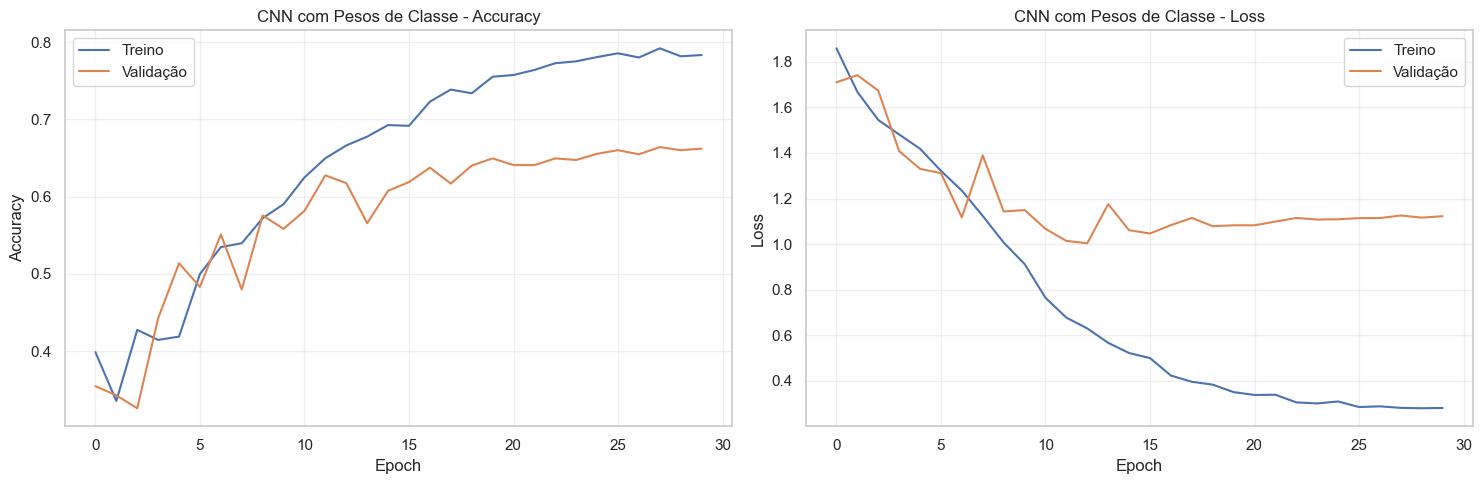

In [117]:
# 4. Curvas de treino/validação
plot_history(history_cnn_weights, model_name="CNN com Pesos de Classe")

A rede **aprende de forma consistente no conjunto de treino** e também melhora de maneira razoável no conjunto de validação, mas em um ritmo mais lento. Observando o gráfico:

- A accuracy de treino sobe até cerca de **79%**, enquanto a de validação estabiliza em torno de **65%**, mantendo um gap moderado entre as curvas;
- A loss de treino cai continuamente, enquanto a loss de validação **diminui nas primeiras épocas e depois se mantém quase estável**, com pequenas oscilações.


In [120]:
model_class_weights = load_model("models/cnn/class_weights.keras")
print("CNN com Pesos de Classe carregada!")

CNN com Pesos de Classe carregada!


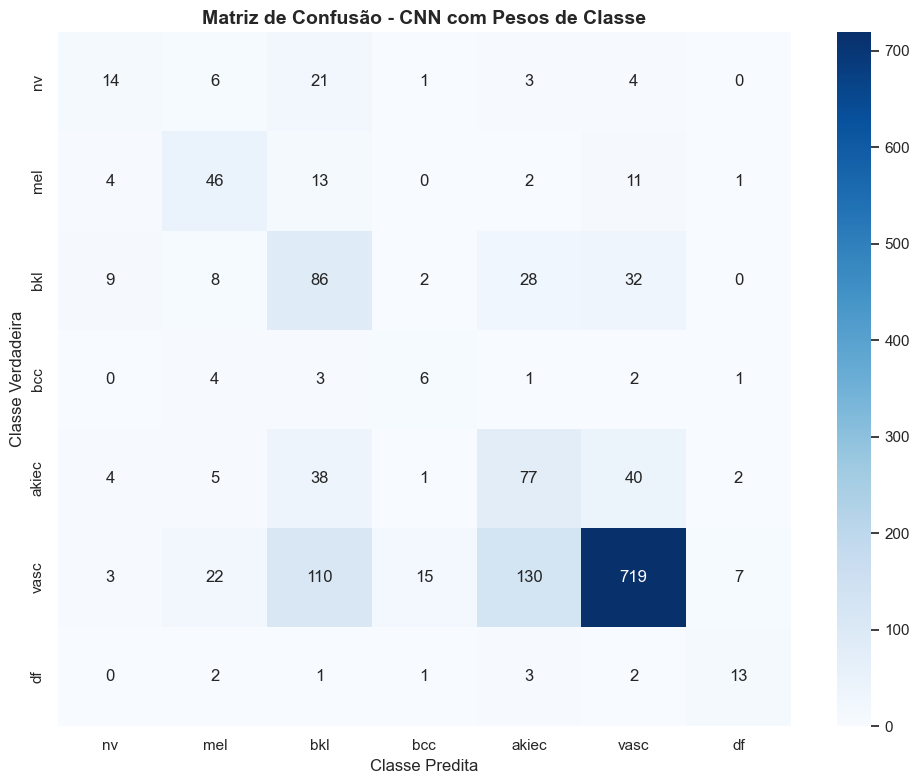

RELATÓRIO DE CLASSIFICAÇÃO - CNN COM PESOS DE CLASSE:
                       precision    recall  f1-score   support

  Nevos melanocíticos     0.4118    0.2857    0.3373        49
             Melanoma     0.4946    0.5974    0.5412        77
    Queratose benigna     0.3162    0.5212    0.3936       165
Carcinoma basocelular     0.2308    0.3529    0.2791        17
   Queratose actínica     0.3156    0.4611    0.3747       167
    Lesões vasculares     0.8877    0.7147    0.7919      1006
       Dermatofibroma     0.5417    0.5909    0.5652        22

             accuracy                         0.6394      1503
            macro avg     0.4569    0.5034    0.4690      1503
         weighted avg     0.7132    0.6394    0.6650      1503



In [121]:
# 5. Avaliação em teste: matriz de confusão + relatório

y_pred_cnn_weights = model_class_weights.predict(X_test, verbose=0)
y_pred_classes_cnn_weights = np.argmax(y_pred_cnn_weights, axis=1)

plot_confusion_and_report(
    y_true=y_test,
    y_pred=y_pred_classes_cnn_weights,
    class_names=class_names,
    model_name="CNN com Pesos de Classe",
)

1. Métricas globais – CNN com Pesos de Classe
  - **Acurácia 63,9%**: menor do que a da CNN simples (~74,1%), mas isso já era esperado ao forçar o modelo a se preocupar mais com classes raras.
  - **Macro avg (média simples entre classes)**:
    - recall médio ≈ **0,50** e F1 ≈ **0,47** → desempenho ainda **médio**, mas com melhor equilíbrio entre as classes do que na CNN simples (que tinha recall macro ≈ 0,45).
  - **Weighted avg (ponderado pelo número de exemplos)**:
    - recall ≈ **0,64**, F1 ≈ **0,67** → pior que na CNN simples (recall ≈ 0,74, F1 ≈ 0,72), pois a performance na classe majoritária caiu, o que puxa a média ponderada para baixo.

  Em resumo: o modelo com pesos de classe **sacrifica acurácia global** e o desempenho na classe dominante para tentar **equilibrar melhor** as classes minoritárias.

2. Métricas por classe – CNN com Pesos de Classe

| Classe                | support | precision | recall | f1-score | Comentário                                                                                                   |
| --------------------- | ------- | --------- | ------ | -------- | ------------------------------------------------------------------------------------------------------------ |
| Nevos melanocíticos   | 49      | 0.41      | 0.29   | 0.34     | Piorou em relação à CNN simples (que tinha recall ~0,45); continua com muitos nevos confundidos com outras lesões. |
| Melanoma              | 77      | 0.49      | 0.60   | 0.54     | **Melhora no recall** (0,52 → 0,60): mais melanomas são detectados, mesmo com leve queda de precisão.              |
| Queratose benigna     | 165     | 0.32      | 0.52   | 0.39     | Recall subiu bastante (0,41 → 0,52), às custas de uma queda de precisão; o modelo passou a “enxergar” mais casos.  |
| Carcinoma basocelular | 17      | 0.23      | 0.35   | 0.28     | Grande ganho de recall (0,12 → 0,35): a rede finalmente começa a **reconhecer essa classe rara**, embora com baixa precisão. |
| Queratose actínica    | 167     | 0.32      | 0.46   | 0.37     | Recall melhor (0,22 → 0,46): praticamente dobra a sensibilidade, com F1 também superior.               |
| Lesões vasculares     | 1006    | 0.89      | 0.71   | 0.79     | Aqui há o principal “preço” pago: recall cai de ~0,93 para ~0,71. A rede deixa de ser tão perfeita na classe majoritária. |
| Dermatofibroma        | 22      | 0.54      | 0.59   | 0.57     | Leve melhora em relação à CNN simples (F1 ~0,59 → ~0,57 bem próximo; recall 0,50 → 0,59), detectando mais casos.   |

3. Comparação com a CNN Simples

- **Acurácia global**: cai de ~74,1% (CNN simples) para ~63,9% (com pesos). O modelo com pesos “erra mais” se olharmos tudo junto, principalmente porque não foca tanto na classe vascular.

- **Equilíbrio entre classes**:
  - O **recall macro** sobe de ~0,45 para ~0,50: em média, as classes são reconhecidas com mais frequência.
  - Classes problemáticas na CNN simples (bcc, akiec, bkl) tiveram **ganhos claros de sensibilidade**, o que é desejável em um cenário clínico.

- **Classe majoritária (Lesões vasculares)**:
  - Perde recall (0,93 → 0,71), mas mantém boa precisão (~0,84 → ~0,89).
  - Isso mostra que os pesos de classe **reduziram o viés extremo** para a classe maior, redistribuindo capacidade para as demais classes.

4. Conclusão

A CNN com pesos de classe **não é melhor em termos de acurácia global**, mas cumpre o objetivo principal dos *class weights*:  ela **equilibra melhor o desempenho entre as classes**, aumentando o recall de várias classes minoritárias (incluindo casos potencialmente críticos, como melanoma e carcinoma basocelular), ao custo de reduzir parte do desempenho na classe majoritária.

Em um contexto clínico, onde falsos negativos em classes raras podem ser mais graves do que erros na classe mais comum, esse trade-off pode ser considerado **mais interessante** do que a CNN simples, mesmo com acurácia total menor. Contudo, o resultado ainda é longe do esperado.

---

### 5. CNN + Oversampling

Na CNN com pesos de classe nós diminuímos o viés para a classe majoritária ajustando a **função de perda**. Agora vamos testar uma abordagem complementar: **oversampling** das classes minoritárias.

A ideia é “aumentar” artificialmente as classes com poucos exemplos, replicando amostras (com reposição) até que todas as classes tenham aproximadamente o mesmo número de imagens. Assim, o modelo vê um conjunto de treino "balanceado", sem precisar alterar a loss via `class_weight`.

---

#### O que é oversampling e por que usar?


O **oversampling** é uma técnica de balanceamento em que:

- identificamos as classes com **menos exemplos**;
- **duplicamos** (ou sintetizamos) amostras dessas classes até que elas tenham um número de exemplos parecido com a classe majoritária.

No nosso caso:

- o dataset HAM10000 é fortemente desbalanceado (lesões vasculares dominam);
- sem tratamento, a CNN tende a focar quase só na classe majoritária;
- com oversampling, fazemos o modelo ver **tantos exemplos de classes raras** quanto de classes comuns, o que pode melhorar o **recall em classes minoritárias**.

Diferentemente dos *class weights*, o oversampling atua **nos dados**: ele cria um novo conjunto de treino balanceado. A função de loss permanece a mesma, mas o gradiente passa a ser influenciado por um número mais justo de exemplos de cada classe.

---

### CNN com Oversampling

In [64]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def hybrid_sampling(X, y, target_count, augmentation_params):
    """
    Balanceamento híbrido: undersample da classe majoritária + 
    oversample das minoritárias até target_count.
    
    Args:
        X: imagens
        y: labels one-hot
        target_count: número alvo de imagens por classe
        augmentation_params: parâmetros do ImageDataGenerator
    
    Returns:
        X_balanced, y_balanced: arrays balanceados
    """
    datagen = ImageDataGenerator(**augmentation_params)
    
    X_balanced = []
    y_balanced = []
    
    for class_idx in range(num_classes):
        # Filtrar imagens da classe atual
        class_mask = np.argmax(y, axis=1) == class_idx
        X_class = X[class_mask].copy()
        y_class = y[class_mask].copy()
        current_count = len(X_class)
        
        # UNDERSAMPLE: se tem mais que o target, reduzir
        if current_count > target_count:
            # Selecionar aleatoriamente target_count amostras
            indices = np.random.choice(current_count, target_count, replace=False)
            X_class = X_class[indices]
            y_class = y_class[indices]
            print(f"  Classe {class_idx} ({list(class_names.keys())[class_idx]}): {current_count} → {target_count} (undersampled)")
        
        # OVERSAMPLE: se tem menos que o target, aumentar
        elif current_count < target_count:
            needed = target_count - current_count
            # Gerar amostras aumentadas
            for _ in range(needed):
                idx = np.random.randint(0, current_count)
                img = X_class[idx:idx+1]
                label = y_class[idx:idx+1]
                aug_img = next(datagen.flow(img, batch_size=1))
                X_class = np.vstack([X_class, aug_img])
                y_class = np.vstack([y_class, label])
            print(f"  Classe {class_idx} ({list(class_names.keys())[class_idx]}): {current_count} → {target_count} (oversampled)")
        
        else:
            print(f"  Classe {class_idx} ({list(class_names.keys())[class_idx]}): {current_count} (mantido)")
        
        X_balanced.append(X_class)
        y_balanced.append(y_class)
    
    # Combinar todas as classes
    X_balanced = np.vstack(X_balanced)
    y_balanced = np.vstack(y_balanced)
    
    # Embaralhar
    shuffle_idx = np.random.permutation(len(X_balanced))
    X_balanced = X_balanced[shuffle_idx]
    y_balanced = y_balanced[shuffle_idx]
    
    return X_balanced, y_balanced

print("✅ Função de balanceamento híbrido criada!")

✅ Função de balanceamento híbrido criada!


In [68]:
# Parâmetros de augmentation
augmentation_params = {
    'rotation_range': 10,
    'zoom_range': 0.1,
    'width_shift_range': 0.1,
    'height_shift_range': 0.1,
    'horizontal_flip': False,
    'vertical_flip': False
}

# Verificar distribuição original
class_counts_original = [np.sum(np.argmax(y_train_encoded, axis=1) == i) for i in range(num_classes)]

print(f"📊 Distribuição original das classes no treino:")
for idx, (code, name) in enumerate(class_names.items()):
    count = class_counts_original[idx]
    print(f"  Classe {idx} ({code:6s}): {count:4d} imagens")

# Definir target (ponto médio estratégico)
# Opções: usar mediana, média, ou valor fixo
median_count = int(np.median(class_counts_original))
mean_count = int(np.mean(class_counts_original))
target_count = 1000  # Valor fixo razoável (ajuste conforme sua RAM)

print(f"\n📈 Estatísticas:")
print(f"   Mínimo: {min(class_counts_original)} imagens")
print(f"   Mediana: {median_count} imagens")
print(f"   Média: {mean_count} imagens")
print(f"   Máximo: {max(class_counts_original)} imagens")
print(f"\n🎯 Target escolhido: {target_count} imagens por classe")

# Calcular memória aproximada
original_size = len(X_train) * X_train[0].nbytes / (1024**3)
balanced_size = (num_classes * target_count) * X_train[0].nbytes / (1024**3)
print(f"\n💾 Uso de memória (aproximado):")
print(f"   Original: {original_size:.2f} GB")
print(f"   Balanceado: {balanced_size:.2f} GB")

# Aplicar balanceamento
print(f"\n⏳ Aplicando balanceamento híbrido...")
X_train_balanced, y_train_balanced = hybrid_sampling(
    X_train, y_train_encoded, target_count, augmentation_params
)

# Verificar distribuição após balanceamento
class_counts_balanced = [np.sum(np.argmax(y_train_balanced, axis=1) == i) for i in range(num_classes)]

print(f"\n✅ Balanceamento concluído!")
print(f"   Total de imagens: {len(X_train_balanced)}")
print(f"\n📊 Distribuição final:")
for idx, (code, name) in enumerate(class_names.items()):
    count = class_counts_balanced[idx]
    print(f"  Classe {idx} ({code:6s}): {count:4d} imagens")

📊 Distribuição original das classes no treino:
  Classe 0 (nv    ):  229 imagens
  Classe 1 (mel   ):  360 imagens
  Classe 2 (bkl   ):  769 imagens
  Classe 3 (bcc   ):   80 imagens
  Classe 4 (akiec ):  779 imagens
  Classe 5 (vasc  ): 4693 imagens
  Classe 6 (df    ):   99 imagens

📈 Estatísticas:
   Mínimo: 80 imagens
   Mediana: 360 imagens
   Média: 1001 imagens
   Máximo: 4693 imagens

🎯 Target escolhido: 1000 imagens por classe

💾 Uso de memória (aproximado):
   Original: 2.57 GB
   Balanceado: 2.56 GB

⏳ Aplicando balanceamento híbrido...
  Classe 0 (nv): 229 → 1000 (oversampled)
  Classe 1 (mel): 360 → 1000 (oversampled)
  Classe 2 (bkl): 769 → 1000 (oversampled)
  Classe 3 (bcc): 80 → 1000 (oversampled)
  Classe 4 (akiec): 779 → 1000 (oversampled)
  Classe 5 (vasc): 4693 → 1000 (undersampled)
  Classe 6 (df): 99 → 1000 (oversampled)

✅ Balanceamento concluído!
   Total de imagens: 7000

📊 Distribuição final:
  Classe 0 (nv    ): 1000 imagens
  Classe 1 (mel   ): 1000 imagens

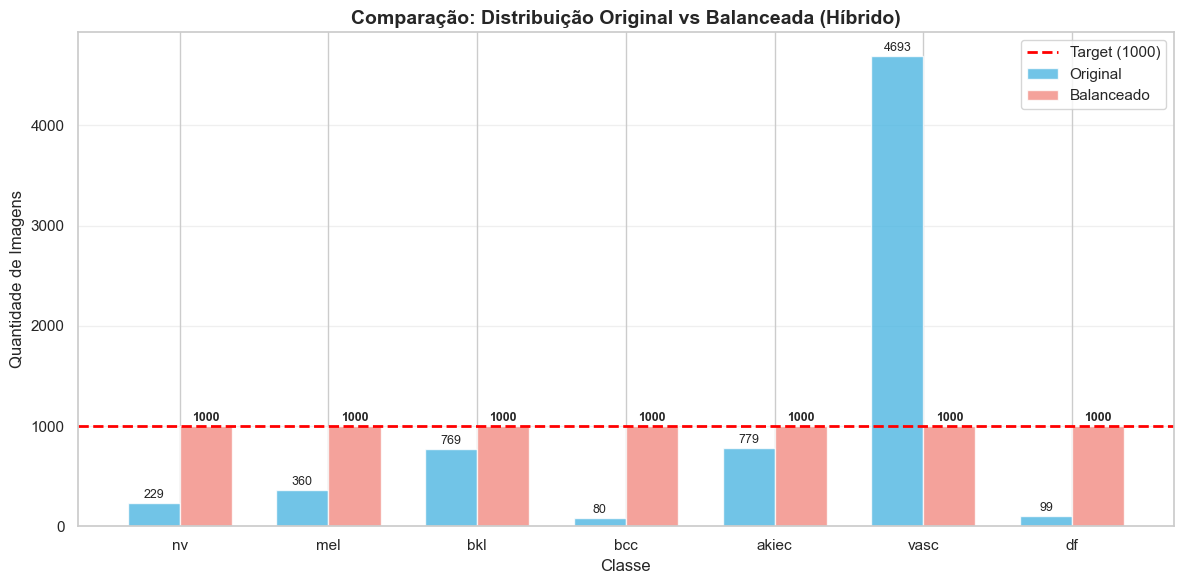

In [69]:
# Plotar comparação
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(class_names))
width = 0.35

bars1 = ax.bar(x - width/2, class_counts_original, width, label='Original', color='#4DB6E2', alpha=0.8)
bars2 = ax.bar(x + width/2, class_counts_balanced, width, label='Balanceado', color='#F28B82', alpha=0.8)

# Linha do target
ax.axhline(y=target_count, color='red', linestyle='--', linewidth=2, label=f'Target ({target_count})')

ax.set_xlabel('Classe', fontsize=12)
ax.set_ylabel('Quantidade de Imagens', fontsize=12)
ax.set_title('Comparação: Distribuição Original vs Balanceada (Híbrido)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(list(class_names.keys()))
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, (v1, v2) in enumerate(zip(class_counts_original, class_counts_balanced)):
    ax.text(i - width/2, v1 + 50, str(v1), ha='center', fontsize=9)
    ax.text(i + width/2, v2 + 50, str(v2), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [70]:
model_cnn_aug = Sequential()
model_cnn_aug.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)))
model_cnn_aug.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
model_cnn_aug.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn_aug.add(Dropout(0.25))

model_cnn_aug.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_cnn_aug.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_cnn_aug.add(MaxPooling2D(pool_size=(2, 2)))
model_cnn_aug.add(Dropout(0.40))

model_cnn_aug.add(Flatten())
model_cnn_aug.add(Dense(128, activation='relu'))
model_cnn_aug.add(Dropout(0.5))
model_cnn_aug.add(Dense(num_classes, activation='softmax'))

model_cnn_aug.summary()

c:\Users\caiog\Documents\INSPER10\PROJETOML\SkinCancer_VisionTransformer_Project\venv311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,455,207 (32.25 MB)

 Trainable params: 8,455,207 (32.25 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
optimizer = Adam(learning_rate=0.001)
model_cnn_aug.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=3,
    verbose=1,
    factor=0.5,
    min_lr=0.00001
)

print("✅ Modelo compilado!")

✅ Modelo compilado!


In [72]:
history_cnn_aug = model_cnn_aug.fit(
    X_train_balanced, y_train_balanced,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val_encoded),
    callbacks=[learning_rate_reduction],
    verbose=1
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 79s 338ms/step - accuracy: 0.3077 - loss: 1.7422 - val_accuracy: 0.3666 - val_loss: 1.7809 - learning_rate: 0.0010
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 60s 275ms/step - accuracy: 0.4617 - loss: 1.4014 - val_accuracy: 0.4644 - val_loss: 1.4559 - learning_rate: 0.0010
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 58s 266ms/step - accuracy: 0.5227 - loss: 1.2414 - val_accuracy: 0.4724 - val_loss: 1.3475 - learning_rate: 0.0010
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 60s 272ms/step - accuracy: 0.5671 - loss: 1.1251 - val_accuracy: 0.4677 - val_loss: 1.3981 - learning_rate: 0.0010
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 58s 266ms/step - accuracy: 0.6380 - loss: 0.9771 - val_accuracy: 0.5316 - val_loss: 1.2232 - learning_rate: 0.0010
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 59s 269ms/step - accuracy: 0.6667 - loss: 0.8705 - val_accuracy: 0.5675 - val_loss: 1.1396 - learning_rate: 0.0010
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 61s 280ms/step - accuracy: 0.7

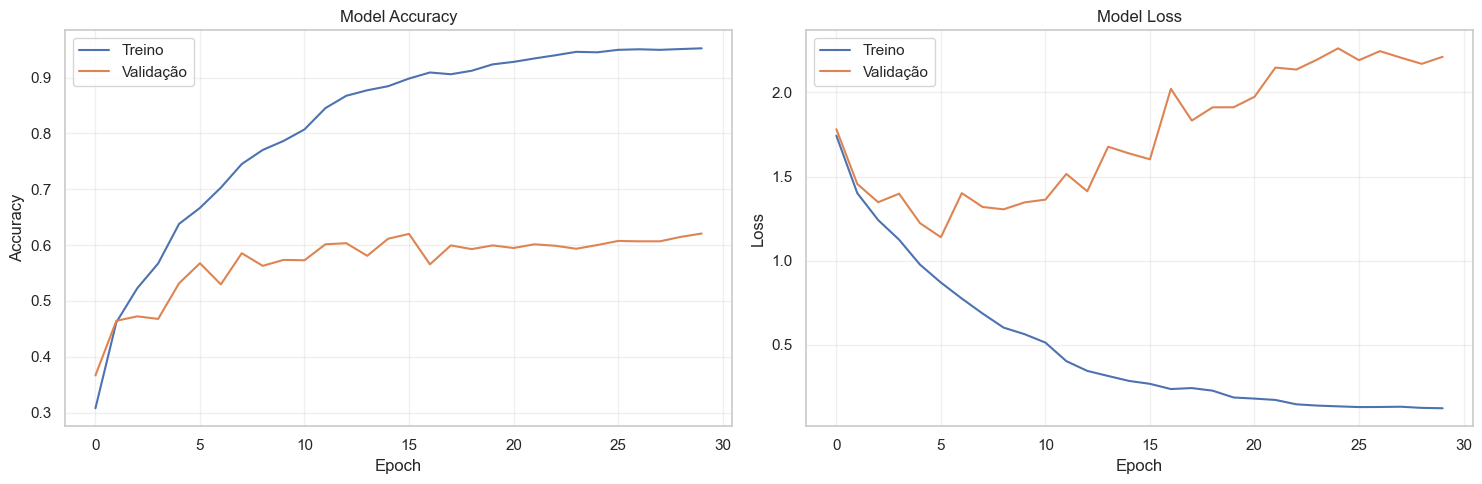

📊 RESULTADOS DA CNN COM DATA AUGMENTATION E OVERSAMPLING
Acurácia Validação: 62.08%
Acurácia Teste:     59.95%
Loss Validação:    2.2106
Loss Teste:        2.3681


In [73]:
# Visualização do treinamento
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history_cnn_aug.history['accuracy'], label='Treino')
axes[0].plot(history_cnn_aug.history['val_accuracy'], label='Validação')
axes[0].set_title('Model Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cnn_aug.history['loss'], label='Treino')
axes[1].plot(history_cnn_aug.history['val_loss'], label='Validação')
axes[1].set_title('Model Loss')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Avaliação
test_loss, test_accuracy = model_cnn_aug.evaluate(X_test, y_test_encoded, verbose=0)
val_loss, val_accuracy = model_cnn_aug.evaluate(X_val, y_val_encoded, verbose=0)

print("="*70)
print("📊 RESULTADOS DA CNN COM DATA AUGMENTATION E OVERSAMPLING")
print("="*70)
print(f"Acurácia Validação: {val_accuracy*100:.2f}%")
print(f"Acurácia Teste:     {test_accuracy*100:.2f}%")
print(f"Loss Validação:    {val_loss:.4f}")
print(f"Loss Teste:        {test_loss:.4f}")
print("="*70)

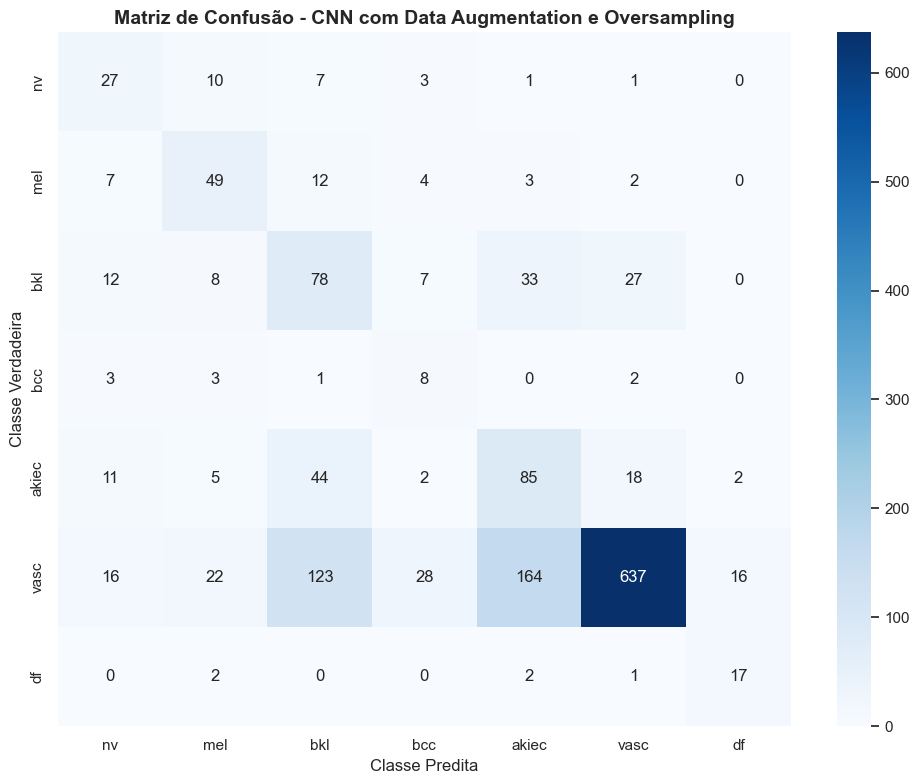


📊 RELATÓRIO DE CLASSIFICAÇÃO - CNN COM DATA AUGMENTATION E OVERSAMPLING
                       precision    recall  f1-score   support

  Nevos melanocíticos     0.3553    0.5510    0.4320        49
             Melanoma     0.4949    0.6364    0.5568        77
    Queratose benigna     0.2943    0.4727    0.3628       165
Carcinoma basocelular     0.1538    0.4706    0.2319        17
   Queratose actínica     0.2951    0.5090    0.3736       167
    Lesões vasculares     0.9259    0.6332    0.7521      1006
       Dermatofibroma     0.4857    0.7727    0.5965        22

             accuracy                         0.5995      1503
            macro avg     0.4293    0.5779    0.4722      1503
         weighted avg     0.7306    0.5995    0.6387      1503



In [74]:
y_pred_cnn_aug = model_cnn_aug.predict(X_test, verbose=0)
y_pred_classes_cnn_aug = np.argmax(y_pred_cnn_aug, axis=1)

# Matriz de confusão
cm_cnn_aug = confusion_matrix(y_test, y_pred_classes_cnn_aug)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn_aug, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(class_names.keys()),
            yticklabels=list(class_names.keys()))
plt.title('Matriz de Confusão - CNN com Data Augmentation e Oversampling', fontsize=14, fontweight='bold')
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Predita')
plt.tight_layout()
plt.show()

# Relatório de classificação
print("\n" + "="*80)
print("📊 RELATÓRIO DE CLASSIFICAÇÃO - CNN COM DATA AUGMENTATION E OVERSAMPLING")
print("="*80)
print(classification_report(
    y_test,
    y_pred_classes_cnn_aug,
    target_names=list(class_names.values()),
    digits=4
))
print("="*80)

📊 COMPARAÇÃO GERAL - TODOS OS MODELOS
          Modelo  Accuracy  Balanced Accuracy  F1-Macro  F1-Weighted
           Dummy  0.669328           0.142857  0.114559     0.536743
     CNN Simples  0.599468           0.392280  0.417658     0.703188
     CNN Weights  0.636727           0.421961  0.397075     0.659541
CNN Augmentation  0.599468           0.577944  0.472240     0.638684

📊 PRECISION POR CLASSE
          Modelo  Nevos melanocíticos  Melanoma  Queratose benigna  Carcinoma basocelular  Queratose actínica  Lesões vasculares  Dermatofibroma
           Dummy             0.000000  0.000000           0.000000               0.000000            0.000000           0.669328        0.000000
     CNN Simples             0.347826  0.550725           0.415663               0.000000            0.361345           0.827928        0.733333
     CNN Weights             0.240000  0.388889           0.327935               0.064516            0.322115           0.878077        0.458333
CNN Augmentat

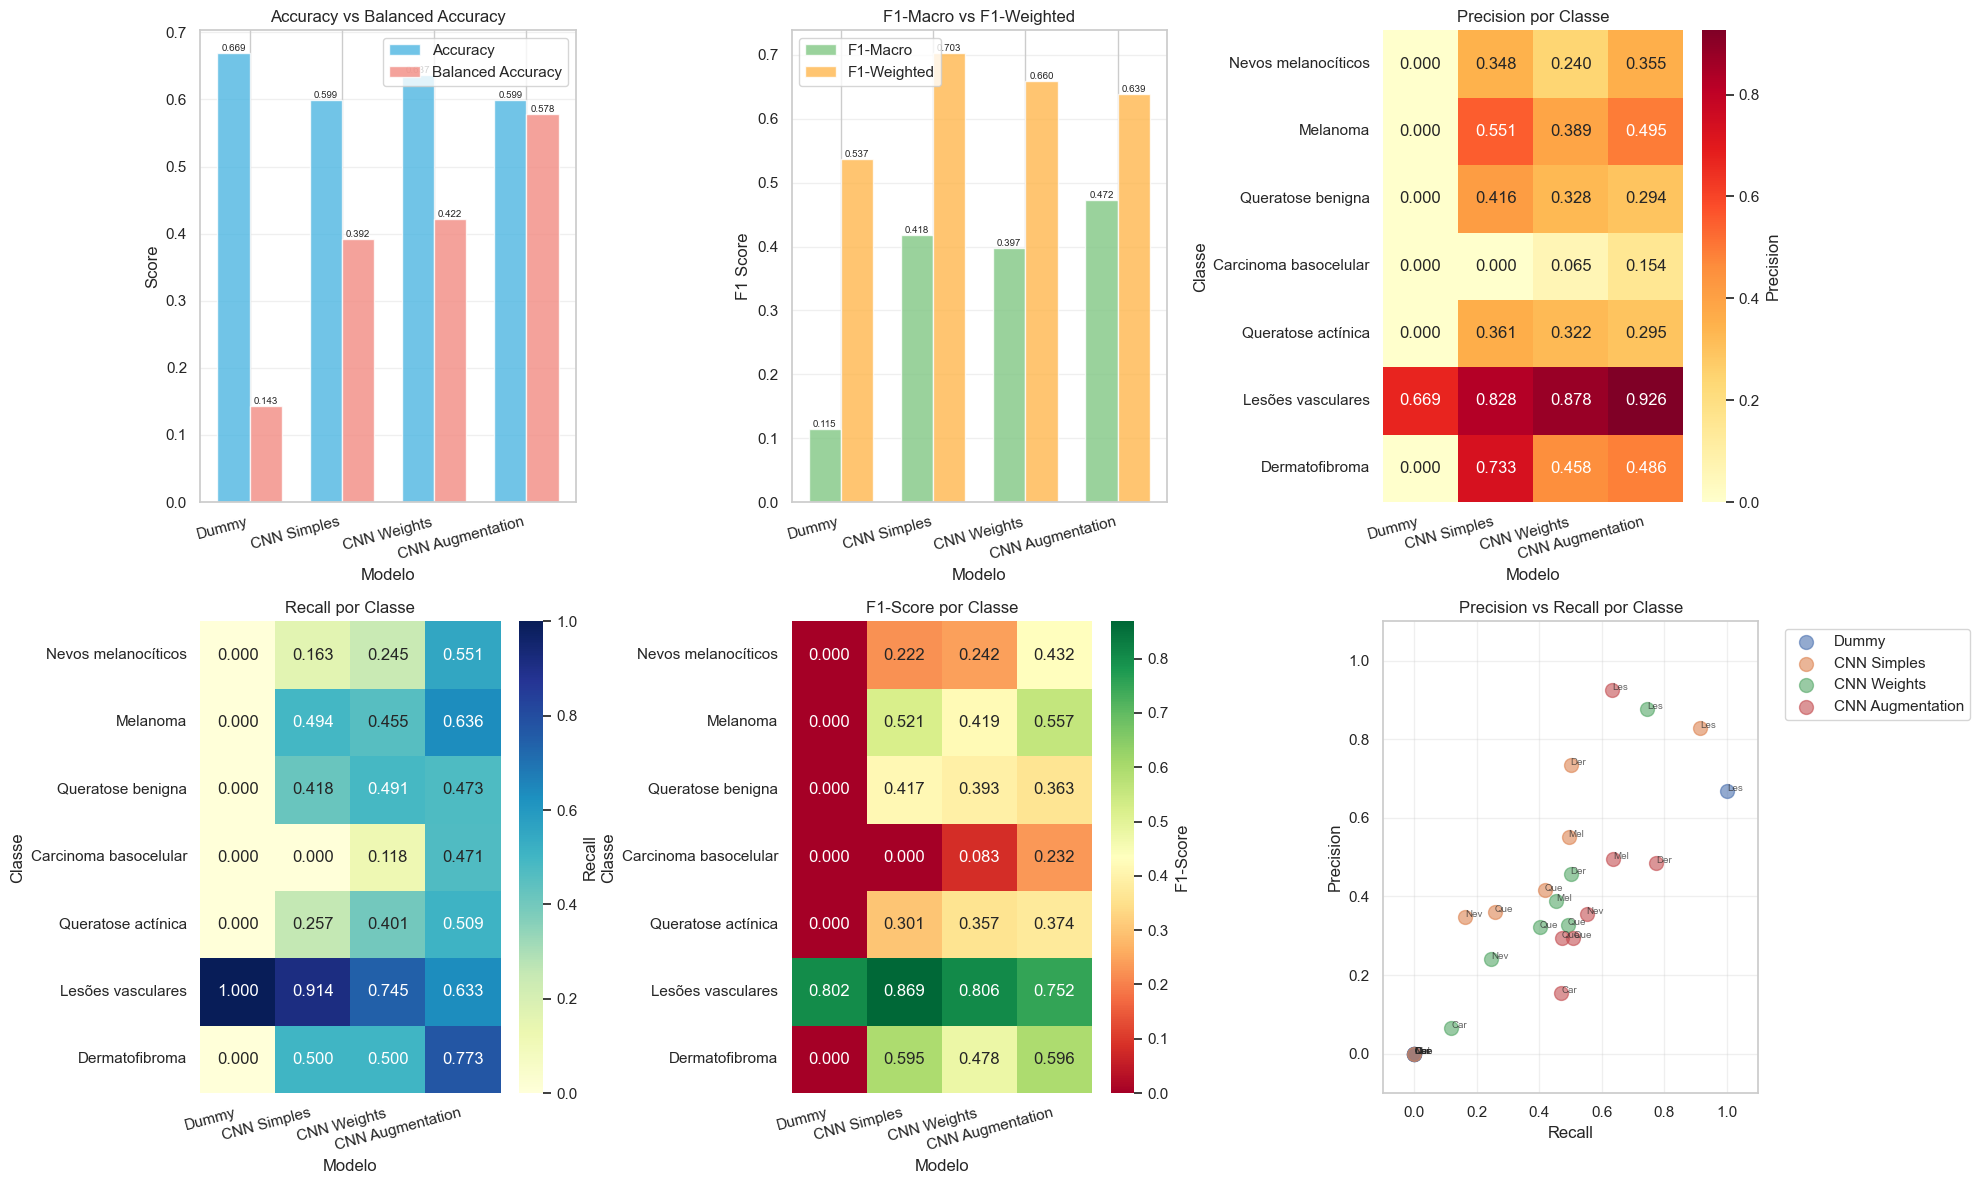


🎯 ANÁLISE DAS CLASSES CRÍTICAS (Melanoma e Carcinoma Basocelular)

📊 Melanoma:
------------------------------------------------------------------------------------------
  Dummy                | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
  CNN Simples          | Precision: 0.5507 | Recall: 0.4935 | F1: 0.5205
  CNN Weights          | Precision: 0.3889 | Recall: 0.4545 | F1: 0.4192
  CNN Augmentation     | Precision: 0.4949 | Recall: 0.6364 | F1: 0.5568

  🏆 Melhor Precision: CNN Simples (0.5507)
  🏆 Melhor Recall: CNN Augmentation (0.6364)
  🏆 Melhor F1: CNN Augmentation (0.5568)

📊 Carcinoma basocelular:
------------------------------------------------------------------------------------------
  Dummy                | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
  CNN Simples          | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
  CNN Weights          | Precision: 0.0645 | Recall: 0.1176 | F1: 0.0833
  CNN Augmentation     | Precision: 0.1538 | Recall: 0.4706 | F1: 0.231

In [77]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score
)

# Calcular métricas por classe para cada modelo
def calculate_metrics_by_class(y_true, y_pred, model_name):
    """Calcula precision e recall por classe."""
    precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    metrics_dict = {}
    for idx, (code, name) in enumerate(class_names.items()):
        metrics_dict[f'{name}_precision'] = precision_per_class[idx]
        metrics_dict[f'{name}_recall'] = recall_per_class[idx]
        metrics_dict[f'{name}_f1'] = f1_per_class[idx]
    
    return metrics_dict

# Coletar métricas de todos os modelos
all_metrics = []

# Dummy
y_pred_dummy = dummy_model.predict(X_test)
all_metrics.append({
    'Modelo': 'Dummy',
    'Accuracy': accuracy_score(y_test, y_pred_dummy),
    'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred_dummy),
    'F1-Macro': f1_score(y_test, y_pred_dummy, average='macro', zero_division=0),
    'F1-Weighted': f1_score(y_test, y_pred_dummy, average='weighted', zero_division=0),
    **calculate_metrics_by_class(y_test, y_pred_dummy, 'Dummy')
})

# CNN Simples
all_metrics.append({
    'Modelo': 'CNN Simples',
    'Accuracy': test_accuracy,
    'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred_classes_cnn_simple),
    'F1-Macro': f1_score(y_test, y_pred_classes_cnn_simple, average='macro', zero_division=0),
    'F1-Weighted': f1_score(y_test, y_pred_classes_cnn_simple, average='weighted', zero_division=0),
    **calculate_metrics_by_class(y_test, y_pred_classes_cnn_simple, 'CNN Simples')
})

# CNN Weights
all_metrics.append({
    'Modelo': 'CNN Weights',
    'Accuracy': accuracy_score(y_test, y_pred_classes_cnn_weights),
    'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred_classes_cnn_weights),
    'F1-Macro': f1_score(y_test, y_pred_classes_cnn_weights, average='macro', zero_division=0),
    'F1-Weighted': f1_score(y_test, y_pred_classes_cnn_weights, average='weighted', zero_division=0),
    **calculate_metrics_by_class(y_test, y_pred_classes_cnn_weights, 'CNN Weights')
})

# CNN Augmentation
all_metrics.append({
    'Modelo': 'CNN Augmentation',
    'Accuracy': accuracy_score(y_test, y_pred_classes_cnn_aug),
    'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred_classes_cnn_aug),
    'F1-Macro': f1_score(y_test, y_pred_classes_cnn_aug, average='macro', zero_division=0),
    'F1-Weighted': f1_score(y_test, y_pred_classes_cnn_aug, average='weighted', zero_division=0),
    **calculate_metrics_by_class(y_test, y_pred_classes_cnn_aug, 'CNN Augmentation')
})

# Criar DataFrames
df_comparison = pd.DataFrame(all_metrics)

# DataFrame com métricas gerais
df_general = df_comparison[['Modelo', 'Accuracy', 'Balanced Accuracy', 'F1-Macro', 'F1-Weighted']]

# DataFrame com precision por classe
precision_cols = [col for col in df_comparison.columns if col.endswith('_precision')]
df_precision = df_comparison[['Modelo'] + precision_cols].copy()
df_precision.columns = ['Modelo'] + [col.replace('_precision', '') for col in precision_cols]

# DataFrame com recall por classe
recall_cols = [col for col in df_comparison.columns if col.endswith('_recall')]
df_recall = df_comparison[['Modelo'] + recall_cols].copy()
df_recall.columns = ['Modelo'] + [col.replace('_recall', '') for col in recall_cols]

# DataFrame com F1 por classe
f1_cols = [col for col in df_comparison.columns if col.endswith('_f1')]
df_f1_class = df_comparison[['Modelo'] + f1_cols].copy()
df_f1_class.columns = ['Modelo'] + [col.replace('_f1', '') for col in f1_cols]

# Exibir métricas gerais
print("="*90)
print("📊 COMPARAÇÃO GERAL - TODOS OS MODELOS")
print("="*90)
print(df_general.to_string(index=False))
print("="*90)

# Exibir Precision por classe
print("\n" + "="*90)
print("📊 PRECISION POR CLASSE")
print("="*90)
print(df_precision.to_string(index=False))
print("="*90)

# Exibir Recall por classe
print("\n" + "="*90)
print("📊 RECALL POR CLASSE")
print("="*90)
print(df_recall.to_string(index=False))
print("="*90)

# Exibir F1 por classe
print("\n" + "="*90)
print("📊 F1-SCORE POR CLASSE")
print("="*90)
print(df_f1_class.to_string(index=False))
print("="*90)

# Visualizações
fig = plt.figure(figsize=(20, 12))

# Gráfico 1: Métricas Gerais
ax1 = plt.subplot(2, 3, 1)
x = np.arange(len(df_general))
width = 0.35
bars1 = ax1.bar(x - width/2, df_general['Accuracy'], width, label='Accuracy', color='#4DB6E2', alpha=0.8)
bars2 = ax1.bar(x + width/2, df_general['Balanced Accuracy'], width, label='Balanced Accuracy', color='#F28B82', alpha=0.8)
ax1.set_xlabel('Modelo')
ax1.set_ylabel('Score')
ax1.set_title('Accuracy vs Balanced Accuracy')
ax1.set_xticks(x)
ax1.set_xticklabels(df_general['Modelo'], rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', 
                ha='center', va='bottom', fontsize=7)

# Gráfico 2: F1 Scores
ax2 = plt.subplot(2, 3, 2)
bars3 = ax2.bar(x - width/2, df_general['F1-Macro'], width, label='F1-Macro', color='#81C784', alpha=0.8)
bars4 = ax2.bar(x + width/2, df_general['F1-Weighted'], width, label='F1-Weighted', color='#FFB74D', alpha=0.8)
ax2.set_xlabel('Modelo')
ax2.set_ylabel('F1 Score')
ax2.set_title('F1-Macro vs F1-Weighted')
ax2.set_xticks(x)
ax2.set_xticklabels(df_general['Modelo'], rotation=15, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', 
                ha='center', va='bottom', fontsize=7)

# Gráfico 3: Precision por Classe (Heatmap)
ax3 = plt.subplot(2, 3, 3)
precision_data = df_precision.set_index('Modelo').T
sns.heatmap(precision_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax3, cbar_kws={'label': 'Precision'})
ax3.set_title('Precision por Classe')
ax3.set_xlabel('Modelo')
ax3.set_ylabel('Classe')
plt.setp(ax3.get_xticklabels(), rotation=15, ha='right')

# Gráfico 4: Recall por Classe (Heatmap)
ax4 = plt.subplot(2, 3, 4)
recall_data = df_recall.set_index('Modelo').T
sns.heatmap(recall_data, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax4, cbar_kws={'label': 'Recall'})
ax4.set_title('Recall por Classe')
ax4.set_xlabel('Modelo')
ax4.set_ylabel('Classe')
plt.setp(ax4.get_xticklabels(), rotation=15, ha='right')

# Gráfico 5: F1 por Classe (Heatmap)
ax5 = plt.subplot(2, 3, 5)
f1_data = df_f1_class.set_index('Modelo').T
sns.heatmap(f1_data, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax5, cbar_kws={'label': 'F1-Score'})
ax5.set_title('F1-Score por Classe')
ax5.set_xlabel('Modelo')
ax5.set_ylabel('Classe')
plt.setp(ax5.get_xticklabels(), rotation=15, ha='right')

# Gráfico 6: Precision vs Recall por Modelo (Scatter)
ax6 = plt.subplot(2, 3, 6)
for idx, model_name in enumerate(df_precision['Modelo']):
    precisions = df_precision.iloc[idx, 1:].values
    recalls = df_recall.iloc[idx, 1:].values
    ax6.scatter(recalls, precisions, label=model_name, s=100, alpha=0.6)
    # Adicionar nome da classe
    for j, class_name in enumerate(df_precision.columns[1:]):
        ax6.annotate(class_name[:3], (recalls[j], precisions[j]), fontsize=7, alpha=0.7)

ax6.set_xlabel('Recall')
ax6.set_ylabel('Precision')
ax6.set_title('Precision vs Recall por Classe')
ax6.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax6.grid(True, alpha=0.3)
ax6.set_xlim([-0.1, 1.1])
ax6.set_ylim([-0.1, 1.1])

plt.tight_layout()
plt.show()

# Análise das classes críticas (melanoma e carcinoma)
print("\n" + "="*90)
print("🎯 ANÁLISE DAS CLASSES CRÍTICAS (Melanoma e Carcinoma Basocelular)")
print("="*90)

critical_classes = ['Melanoma', 'Carcinoma basocelular']
for class_name in critical_classes:
    precision_col = f'{class_name}_precision'
    recall_col = f'{class_name}_recall'
    f1_col = f'{class_name}_f1'
    
    print(f"\n📊 {class_name}:")
    print("-" * 90)
    for idx, row in df_comparison.iterrows():
        print(f"  {row['Modelo']:20s} | Precision: {row[precision_col]:.4f} | Recall: {row[recall_col]:.4f} | F1: {row[f1_col]:.4f}")
    
    # Melhor modelo para esta classe
    best_precision_idx = df_comparison[precision_col].idxmax()
    best_recall_idx = df_comparison[recall_col].idxmax()
    best_f1_idx = df_comparison[f1_col].idxmax()
    
    print(f"\n  🏆 Melhor Precision: {df_comparison.loc[best_precision_idx, 'Modelo']} ({df_comparison.loc[best_precision_idx, precision_col]:.4f})")
    print(f"  🏆 Melhor Recall: {df_comparison.loc[best_recall_idx, 'Modelo']} ({df_comparison.loc[best_recall_idx, recall_col]:.4f})")
    print(f"  🏆 Melhor F1: {df_comparison.loc[best_f1_idx, 'Modelo']} ({df_comparison.loc[best_f1_idx, f1_col]:.4f})")

print("\n" + "="*90)
print("💡 Interpretação:")
print("   • Precision: Quando o modelo prediz a classe, qual % está correto?")
print("   • Recall: Das amostras reais da classe, quantas o modelo detectou?")
print("   • Para diagnóstico médico, RECALL é mais crítico (não perder casos)")
print("="*90)

### Redes Neurais Convolucionais (CNNs)

### Visual Transformer

### Gráficos

### CNN com Metadata

### Fine-Tuning CNN (Modelo XXXX)

### Resultados

## Implementação Visual Transformer

### Visual Transformer

### Fine-Tuning Visual Transformer (Modelo XXXX)

### Resultados

## Comparação

## Conclusão